<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">
<div style=" padding: 30px; border-radius: 12px; text-align: center;  margin-bottom: 20px;">
  <p style="margin:0; font-size:2.2em; font-weight:700;">🛒 Brazilian E-Commerce (Olist) — EDA Notebook</p>

</div>

---

**Dataset:** [Kaggle: Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)  
**Goal:** Demonstrate Univariate, Bivariate, Pattern Discovery, and Multivariate EDA on a real-world e-commerce dataset, then synthesise the findings into a comprehensive dashboard.

---
</div>

> *This notebook is prepared with AI aid.*

In [1]:
from IPython.display import display, HTML

display(
    HTML(
        """
<style>
  .jp-MarkdownOutput {
    font-family: 'Anthropic Sans', sans-serif;
    font-size: 16px;
    line-height: 1.7;
    max-width: 800px;
  }
  .jp-MarkdownOutput blockquote {
    border-left: 3px solid steelblue;
    padding: 15px;
    border-radius: 3px;
    margin: 0;
  }
</style>
"""
    )
)

<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

## 📌 What is Exploratory Data Analysis (EDA)?

> *"The greatest value of a picture is when it forces us to notice what we never expected to see."* — **John Tukey**

**Exploratory Data Analysis (EDA)** is the process of **summarizing, visualizing, and understanding the structure and patterns in a dataset** — before applying any formal modeling techniques.

<p style="font-weight:bold; font-size:1.1em;">Why does EDA matter?</p>

| Reason | Detail |
|---|---|
| 🔍 **Understanding Data Structure** | Reveals the organization, dimensions, and relationships within data |
| 🧹 **Quality Assessment** | Uncovers missing values, outliers, and inconsistencies (EDA and cleaning can be iterative) |
| 💡 **Feature Discovery** | Identifies relevant features and relationships for modeling |
| 📢 **Insight Communication** | Translates raw numbers into clear visual stories for stakeholders |

<p style="font-weight:bold; font-size:1.1em;">EDA Workflow</p>

```
Univariate Analysis → Bivariate Analysis → Multivariate Analysis → Insight Communication
```

Each stage builds on the previous one:
- **Univariate**: Understand each variable *alone*
- **Bivariate**: Understand how *two* variables relate
- **Multivariate**: Understand *three or more* variables simultaneously
- **Insight Communication**: Dashboards, reports, visualizations
</div>

<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

## 1. Dataset Overview

<div style=" border-left:5px solid #1B6CA8; padding:15px; border-radius:4px; margin:10px 0;">
<strong>Why this dataset?</strong><br>
It is rich in <em>every variable type</em> — continuous prices, categorical regions, temporal timestamps, and ordinal ratings. This mirrors what real e-commerce data scientists work with daily. The <strong>Black Friday 2017 spike</strong> is a memorable teaching moment for pattern discovery.
</div>

<p style="font-weight:bold; font-size:1.1em;">Dataset at a Glance</p>

| Property | Value |
|---|---|
| **Source** | Kaggle: Brazilian E-Commerce Public Dataset by Olist |
| **Size** | ~100,000 orders (2016–2018), 9 relational CSV files |
| **Time span** | September 2016 – August 2018 |

<p style="font-weight:bold; font-size:1.1em;">Files We Will Use</p>

| File | Description |
|---|---|
| `olist_orders_dataset.csv` | One row per order: `order_id`, `customer_id`, timestamps |
| `olist_order_items_dataset.csv` | One row per item in an order: `price`, `freight_value`, `seller_id` |
| `olist_order_reviews_dataset.csv` | Customer reviews: `review_score` (1–5 stars) |
| `olist_customers_dataset.csv` | Customer info: `customer_id`, `customer_state` |

<p style="font-weight:bold; font-size:1.1em;">Key Variables</p>

| Variable | Type | Description |
|---|---|---|
| `price` | Continuous | Item price in Brazilian Real (R$) |
| `freight_value` | Continuous | Shipping cost in R$ |
| `review_score` | Ordinal (1–5) | Customer satisfaction rating |
| `order_purchase_timestamp` | DateTime | When the order was placed |
| `customer_state` | Categorical | Brazilian state abbreviation (e.g., SP, RJ) |
| `order_delivered_customer_date` | DateTime | When the order arrived |
| `delivery_days` | Derived Continuous | Calculated: delivered_date − purchase_date |

<p style="font-weight:bold; font-size:1.1em;">Learning Objectives</p>

- ✅ Identify skewed distributions and choose appropriate visualizations
- ✅ Explore how delivery performance relates to customer satisfaction
- ✅ Detect temporal patterns and anomalies (Black Friday spike)
- ✅ Build a customer satisfaction monitoring dashboard
</div>

<div style="max-width: 900px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

## 2. Setup & Data Loading

<p style="font-weight:bold; font-size:1.1em;">📚 A Quick Introduction to Our Main Libraries</p>

Before we write the setup code, let's understand the key libraries and their common patterns.

---

<p style="font-weight:bold; font-size:1.1em;">🔷 Matplotlib — The Foundation</p>

`matplotlib.pyplot` is the core plotting engine. Almost every plot ultimately uses it.

**Common parameters shared across most plot functions:**

| Parameter | What it controls | Example values |
|---|---|---|
| `figsize` | Figure size in inches `(width, height)` | `(12, 6)`, `(8, 8)` |
| `dpi` | Dots-per-inch (resolution) | `100`, `150`, `300` |
| `color` / `c` | Color of the element | `'#1B6CA8'`, `'blue'`, `'red'` |
| `alpha` | Opacity (opposite of Transparency) (0=invisible, 1=opaque) | `0.3`, `0.8` |
| `label` | Legend label for this element | `'Revenue'`, `'2023'` |
| `linewidth` / `lw` | Line thickness in points | `1.5`, `2.0` |
| `edgecolor` | Border color of bars/patches | `'white'`, `'black'` |
| `fontsize` | Text size in points | `10`, `12`, `'bold'` |
| `fontweight` | Text weight | `'bold'`, `'normal'` |

**The `fig, ax` / `fig, axes` pattern:**

```python
# Single plot
fig, ax = plt.subplots(figsize=(8, 5))

# Multiple plots in a grid (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# axes[0] is the left plot, axes[1] is the right plot

# Multiple plots in a 2×2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# axes[0][0] = top-left, axes[0][1] = top-right, etc.
```

The `tight_layout()` call adjusts spacing so subplots don't overlap.

---

<p style="font-weight:bold; font-size:1.1em;">🔶 Seaborn — Statistical Visualizations</p>

Seaborn is built on top of Matplotlib and provides higher-level functions for statistical plots.

**Common parameters shared across most seaborn functions:**

| Parameter | Meaning | Example |
|---|---|---|
| `data` | The DataFrame to plot from | `data=df` |
| `x` | Column name for the x-axis | `x='price'` |
| `y` | Column name for the y-axis | `y='review_score'` |
| `hue` | Column name for color grouping | `hue='customer_state'` |
| `palette` | Color scheme for hue groups | `'Set2'`, `'viridis'`, `{'A':'red'}` |
| `ax` | Which matplotlib axis to draw on | `ax=axes[0]` |
| `fill` | Fill area under curve (KDE) | `True`, `False` |

**Similarity across Matplotlib & Seaborn:**  
Both use `ax=` to target specific subplots. Both accept `color`, `alpha`, `label`. Seaborn simply adds smarter defaults and statistical features on top.

---
</div>

In [2]:
# ============================================================
# EXAMPLE 1: Brazilian E-Commerce (Olist) Dataset
# Dataset: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
# Install: pip install pandas matplotlib seaborn scipy
# ============================================================

import pandas as pd  # Data manipulation and analysis
import numpy as np  # Numerical computing
import matplotlib.pyplot as plt  # Core plotting (the matplotlib.pyplot module)
import matplotlib.gridspec as gridspec  # Custom grid layouts for dashboards
import seaborn as sns  # Statistical visualizations (built on matplotlib)
from scipy import stats  # Statistical functions (linregress, etc.)
from datetime import timedelta


# ── Global Style Settings ─────────────────────────────────────────────────
# These settings affect ALL plots in this notebook
# rcParams — short for "runtime configuration parameters",
# a dictionary that stores all default plot settings (colors, font sizes, line widths, DPI, etc.)
plt.rcParams.update(
    {
        'figure.dpi': 120,  # Higher DPI = sharper plots on screen
        'axes.spines.top': False,  # Remove top border from all plots
        'axes.spines.right': False,  # Remove right border from all plots
        'axes.grid': True,  # Show grid lines by default
        'grid.alpha': 0.3,  # Make grid lines semi-transparent
        'grid.linestyle': '--',  # Dashed grid lines
        'font.family': 'sans-serif',  # Clean font
    }
)

print("✅ Libraries imported successfully")
print(f"   pandas   version: {pd.__version__}")
print(f"   numpy    version: {np.__version__}")
print(f"   matplotlib version: {plt.matplotlib.__version__}")
print(f"   seaborn  version: {sns.__version__}")

✅ Libraries imported successfully
   pandas   version: 3.0.1
   numpy    version: 2.4.2
   matplotlib version: 3.10.8
   seaborn  version: 0.13.2


<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="font-weight:bold; font-size:1.15em;">🔍 Code Walkthrough — Imports & Global Style</p>

| Line | What it does |
|---|---|
| `import pandas as pd` | Loads pandas — `pd` is the universal alias |
| `import numpy as np` | Loads NumPy for array math — `np` is the universal alias |
| `import matplotlib.pyplot as plt` | The plotting interface — `plt` is the universal alias |
| `import matplotlib.gridspec as gridspec` | Enables custom dashboard grid layouts |
| `import seaborn as sns` | Statistical plots — `sns` is the universal alias |
| `from scipy import stats` | Statistical tools (we'll use `stats.linregress`) |

**`plt.rcParams.update({...})`** — This is Matplotlib's global configuration dictionary.  
Think of it as *setting default values once* so you don't repeat the same parameters in every plot.  
- `'axes.spines.top': False` removes the top border line from every plot → cleaner look  
- `'grid.alpha': 0.3` makes grid lines faint so they don't compete with data

</div>

In [3]:
# ─── Load the 4 CSV files we need ──────────────────────────────────────────
# Make sure all CSV files are in your working directory first.

orders = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')

print(f'\norders: \n{orders.dtypes}')
print(f'\norder_items: \n{order_items.dtypes}')
print(f'\nreviews: \n{reviews.dtypes}')
print(f'\ncustomers: \n{customers.dtypes}')

# ─── Parse date columns ────────────────────────────────────────────────────
# Pandas reads dates as plain strings by default.
# pd.to_datetime() converts them to proper datetime objects so we can
# do arithmetic (e.g., subtract two dates to get number of days).
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# ─── Merge all tables into one working DataFrame ───────────────────────────
# We use inner join so we only keep orders that exist in ALL tables.
# 'on' specifies the key column that links the tables.
df = orders.merge(order_items, on='order_id', how='inner')

# Left join for reviews: keep all orders even if review is missing
df = df.merge(reviews[['order_id', 'review_score']], on='order_id', how='left')

# Left join for customer state
df = df.merge(
    customers[['customer_id', 'customer_state']], on='customer_id', how='left'
)

# ─── Derive: Delivery Time in Days ─────────────────────────────────────────
# errors='coerce' converts unparseable strings to NaT (Not a Time) instead of crashing
df['order_delivered_customer_date'] = pd.to_datetime(
    df['order_delivered_customer_date'], errors='coerce'
)

# Subtract datetime columns → gives a timedelta, then .dt.days → integer days
df['delivery_days'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.days

# ─── Derive: Monthly Order Volume ──────────────────────────────────────────
# set_index() makes timestamp the index so .resample() can group by time period
# 'ME' = Month End frequency — counts unique order_ids per calendar month
monthly = (
    df.set_index('order_purchase_timestamp')
    .resample('ME')['order_id']
    .nunique()
    .reset_index()
)
monthly.columns = ['month', 'order_count']  # Rename for clarity

print("=" * 60)
print(f"\n✅ Data loaded and merged")
print(f"Shape of merged DataFrame: {df.shape}")
print(f"\nColumns: \n{df.dtypes}")
print(f"\nFirst 3 rows:")
print(df.head(3).to_string(index=False))

print("=" * 60)
print(f"Shape of monthly DataFrame: {monthly.shape}")
print(f"\nColumns: \n{monthly.dtypes}")
print(f"\nFirst 3 rows:")
print(monthly.head(3).to_string(index=False))


orders: 
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

order_items: 
order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object

reviews: 
review_id                    str
order_id                     str
review_score               int64
review_comment_title         str
review_comment_message       str
review_creation_date         str
review_answer_timestamp      str
dtype: object

customers: 
customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state               

<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="font-weight:bold; font-size:1.15em;">

🔍 Code Walkthrough — Loading & Merging Data</p>

<p style="font-weight:bold; font-size:1.15em;">

`pd.read_csv(filename)`</p>
Reads a CSV file into a DataFrame.
- **Input:** path to `.csv` file (string)
- **Output:** `pd.DataFrame`

<p style="font-weight:bold; font-size:1.15em;">

`pd.to_datetime(series, errors='coerce')`</p>
Converts a string column to datetime objects.
- `errors='coerce'` → bad dates become `NaT` (Not a Time) instead of raising an error
- After conversion, you can use `.dt.days`, `.dt.month`, `.dt.day_name()`, etc.

<p style="font-weight:bold; font-size:1.15em;">

`df.merge(other, on='key', how='type')`</p>
Joins two DataFrames on a shared column — like SQL JOIN.

| `how=` | Keeps | Use when |
|---|---|---|
| `'inner'` | Only rows matching in **both** tables | You need complete records |
| `'left'` | All rows from **left** table (fills missing right with NaN) | You want to keep all left rows even without a match |
| `'outer'` | All rows from **both** tables | You want everything |

<p style="font-weight:bold; font-size:1.15em;">

`.resample('ME')`</p>
Groups a time-indexed DataFrame by time period.  
- `'ME'` = Month End, `'D'` = Day, `'YE'` = Year End, `'W'` = Week  
- Must be called on a DataFrame whose index is a datetime type  
- Chain `.nunique()` to count unique values, `.sum()` to total, `.mean()` to average

```python
monthly = (
    df.set_index('order_purchase_timestamp')
    .resample('ME')['order_id']
    .nunique()
    .reset_index()
)
monthly.columns = ['month', 'order_count']  # Rename for clarity
```

**Explanation:**

**Step 1: `df.set_index('order_purchase_timestamp')`**
Sets the purchase timestamp column as the DataFrame index.
This is required for time-based resampling.

| index | order_id | ... |
|-------|----------|-----|
| 2017-01-01 | abc123 | ... |
| 2017-01-15 | def456 | ... |

**Step 2: `.resample('ME')`**
Groups the data into monthly buckets.
`'ME'` = Month End (last day of each month is used as the label).

**Step 3: `['order_id'].nunique()`**
For each monthly bucket, counts the number of **unique** order IDs.
This gives us how many distinct orders were placed each month.

| order_purchase_timestamp | order_id |
|--------------------------|----------|
| 2017-01-31 | 452 |
| 2017-02-28 | 701 |
| 2017-03-31 | 889 |

**Step 4: `.reset_index()`**
Converts the index back into a regular column,
giving us a clean flat DataFrame.

**Step 5: `monthly.columns = ['month', 'order_count']`**
Renames the columns for clarity.

**Final Output**

| month | order_count |
|-------|-------------|
| 2017-01-31 | 452 |
| 2017-02-28 | 701 |
| 2017-03-31 | 889 |
| ... | ... |

Each row = one month, with the total number of unique orders placed that month.

</div>

In [4]:
# ─── Quick Sanity Check of the Data ───────────────────────────────────────

print("=== Shape ===")
print(f"  Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")

print("\n=== Data Types & Missing Values ===")
# Create a summary DataFrame
summary = pd.DataFrame(
    {
        'dtype': df.dtypes,
        'non_null': df.count(),
        'missing': df.isnull().sum(),
        'missing%': (df.isnull().sum() / len(df) * 100).round(1),
    }
)
print(summary)

print("\n=== Descriptive Statistics (numeric columns) ===")
# describe() gives: count, mean, std, min, 25%, 50%, 75%, max
df[['price', 'freight_value', 'review_score', 'delivery_days']].describe().round(2)

=== Shape ===
  Rows: 113,314  |  Columns: 17

=== Data Types & Missing Values ===
                                        dtype  non_null  missing  missing%
order_id                                  str    113314        0       0.0
customer_id                               str    113314        0       0.0
order_status                              str    113314        0       0.0
order_purchase_timestamp       datetime64[us]    113314        0       0.0
order_approved_at                         str    113299       15       0.0
order_delivered_carrier_date              str    112111     1203       1.1
order_delivered_customer_date  datetime64[us]    110839     2475       2.2
order_estimated_delivery_date             str    113314        0       0.0
order_item_id                           int64    113314        0       0.0
product_id                                str    113314        0       0.0
seller_id                                 str    113314        0       0.0
shipping_limit_da

,price,freight_value,review_score,delivery_days
count,113314.00,113314.00,112372.00,110839.00
mean,120.48,19.98,4.03,12.01
std,183.28,15.78,1.39,9.45
min,0.85,0.00,1.00,0.00
25%,39.90,13.08,4.00,6.00
50%,74.90,16.26,5.00,10.00
75%,134.90,21.15,5.00,15.00
max,6735.00,409.68,5.00,209.00


<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

> **💡 Insight Preview:** Notice that `price` will show `mean >> median (50%)` — this signals a **right-skewed distribution** that we'll visualize next.

</div>

<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

## 3. Univariate Analysis

<div style=" border-left:5px solid #2E8B6E; padding:15px; border-radius:4px; margin:10px 0;">
<strong>Goal of Univariate Analysis:</strong> Understand each variable <em>independently</em> before looking for relationships. For price, we expect a right skew (most orders are cheap; a few are very expensive). We use three complementary plots to see this from different angles.
</div>

<p style="font-weight:bold; font-size:1.1em;">What is a Histogram?</p>

A histogram divides a continuous variable into **bins** (intervals) and shows how many data points fall in each bin.

**What to look for:**
- **Central tendency** — where is the peak (mode)?
- **Spread** — how wide is the distribution?
- **Shape** — symmetric, right-skewed, left-skewed, bimodal?
- **Outliers** — isolated bars far from the main mass?

**Key choice: number of bins**

| Rule | Formula | Best for |
|---|---|---|
| Sturges' Rule | `k = 1 + log₂(n)` | Small datasets |
| Freedman-Diaconis | `bin_width = 2 × IQR / n^(1/3)` | Large datasets with outliers |
| Square root | `k = √n` | Quick default |

In Matplotlib: `ax.hist(data, bins=50)` — you set `bins` manually.  
In Seaborn: `sns.histplot(data, bins=50)` — or use `bins='auto'` to let it decide.

---

<p style="font-weight:bold; font-size:1.1em;">What is a KDE Plot (Kernel Density Estimation)?</p>

**KDE** is a non-parametric method for estimating the **probability density function (PDF)** of a continuous variable. Instead of bins, it fits a smooth "kernel" (usually a Gaussian bell curve) at each data point and sums them into one smooth curve.

- **Bandwidth** controls smoothness — like bin width in a histogram
- Use `fill=True` to shade the area under the curve
- Great for revealing **multimodality** (multiple peaks) that histograms might miss

In Seaborn: `sns.kdeplot(data=series, fill=True, alpha=0.4)`

---

<p style="font-weight:bold; font-size:1.1em;">What is a Box Plot?</p>

A box plot (box-and-whisker) summarizes 5 key statistics:

```
         ┌───────────┐
  ───|───│    IQR    │───|───   outliers: ●   ●
         └───────────┘
  min  Q1  median  Q3  max*
```

| Element | Meaning |
|---|---|
| **Box** | Contains the middle 50% of data (IQR = Q3 − Q1) |
| **Line in box** | Median (50th percentile) |
| **Whiskers** | Extend to min/max within 1.5 × IQR |
| **Dots beyond whiskers** | Statistical **outliers** |

Box plots are fast to compare groups, but they hide the distribution *shape* (bimodality, skewness). That's why we use KDE alongside them.

---

<p style="font-weight:bold; font-size:1.1em;">Why These Three Together?</p>

| Plot | Strength | Weakness |
|---|---|---|
| Histogram | Shows bin-level frequency detail | Sensitive to bin choice |
| KDE | Reveals smooth shape (multimodality, tails) | Hides exact counts |
| Box Plot | Immediately shows IQR, median, outliers | Hides shape |

Together they give a **complete picture** of the distribution.

---
</div>

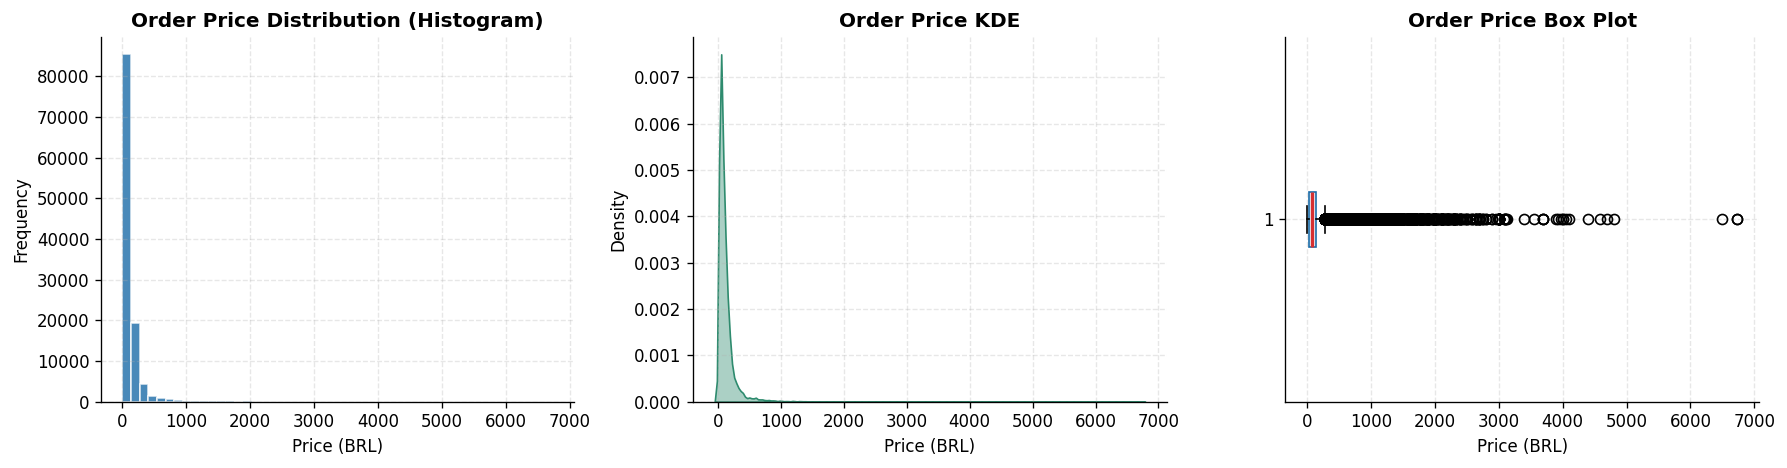

Mean price:   R$ 120.48
Median price: R$ 74.90
Skew indicator: mean > median → RIGHT-skewed

count    113314.00
mean        120.48
std         183.28
min           0.85
25%          39.90
50%          74.90
75%         134.90
max        6735.00
Name: price, dtype: float64


In [5]:
# ─── 1. UNIVARIATE: Distribution of Order Prices ──────────────────────────
# WHY: Price is right-skewed (few very expensive orders).
# Histogram + KDE together show both frequency and shape.

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# Creates a figure with 1 row and 3 columns of subplots
# axes[0] = histogram, axes[1] = KDE, axes[2] = box plot

# ─── Plot 1a: Histogram ────────────────────────────────────────────────────
axes[0].hist(
    df['price'].dropna(),  # Remove NaN values before plotting
    bins=50,  # Number of bins (try 20–100 for continuous data)
    color='#1B6CA8',  # Blue fill color (hex code)
    alpha=0.8,  # 80% opacity — slightly transparent
    edgecolor='white',  # White lines between bars for visual separation
)
axes[0].set_title(
    'Order Price Distribution (Histogram)', fontsize=12, fontweight='bold'
)
axes[0].set_xlabel('Price (BRL)')  # BRL = Brazilian Real
axes[0].set_ylabel('Frequency')  # Y-axis = count of orders in each bin

# ─── Plot 1b: KDE ─────────────────────────────────────────────────────────
sns.kdeplot(
    df['price'].dropna(),  # The data series
    ax=axes[1],  # Which subplot to draw on
    color='#2E8B6E',  # Green color
    fill=True,  # Shade the area under the curve
    alpha=0.4,  # Transparency for the filled area
)
axes[1].set_title('Order Price KDE', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Price (BRL)')
# No ylabel needed — KDE y-axis is "density" (probability per unit)

# ─── Plot 1c: Box Plot ─────────────────────────────────────────────────────
axes[2].boxplot(
    df['price'].dropna(),
    vert=False,  # Horizontal layout (easier to read long tails)
    patch_artist=True,  # Required to fill the box with color
    boxprops=dict(
        facecolor='#EBF4FB', color='#1B6CA8'  # Light blue box fill  # Box border color
    ),
    medianprops=dict(
        color='#D63031',  # Red median line (stands out clearly)
        linewidth=2,  # Thick median line
    ),
)
axes[2].set_title('Order Price Box Plot', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Price (BRL)')

plt.tight_layout()  # Adjusts spacing between subplots to prevent overlap
plt.savefig('olist_univariate_price.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── Print summary statistics ──────────────────────────────────────────────
mean_price = df['price'].mean()
median_price = df['price'].median()
print(f"Mean price:   R$ {mean_price:.2f}")
print(f"Median price: R$ {median_price:.2f}")
print(
    f"Skew indicator: mean {'>' if mean_price > median_price else '<'} median → {'RIGHT' if mean_price > median_price else 'LEFT'}-skewed"
)
print()
print(df['price'].describe().round(2))

<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="font-weight:bold; font-size:1.15em;">

🔍 Code Walkthrough — Plot 1: Histogram + KDE + Box Plot</p>

<p style="font-weight:bold; font-size:1.15em;">

`fig, axes = plt.subplots(1, 3, figsize=(15, 4))`</p>
- Creates **1 row × 3 columns** of subplots
- `figsize=(15, 4)` → 15 inches wide, 4 inches tall
- Returns `fig` (the whole figure) and `axes` (array of 3 Axes objects)

<p style="font-weight:bold; font-size:1.15em;">

`axes[0].hist(data, bins=50, color=..., alpha=..., edgecolor=...)`</p>
**Key parameters:**

| Parameter | Type | Purpose |
|---|---|---|
| `data` | array-like | The values to bin. Always `.dropna()` first! |
| `bins` | int or list | Number of bins, or explicit bin edges |
| `color` | str | Fill color (hex `'#RRGGBB'` or name `'steelblue'`) |
| `alpha` | float 0–1 | Opacity: 0=invisible, 1=solid |
| `edgecolor` | str | Color of bar outlines — `'white'` creates clear separation |

<p style="font-weight:bold; font-size:1.15em;">

`sns.kdeplot(data, ax=axes[1], color=..., fill=True, alpha=...)`</p>
- `fill=True` shades the area under the density curve
- `alpha` controls the transparency of the fill
- The y-axis of a KDE is **density** (not count), so it integrates to 1.0

<p style="font-weight:bold; font-size:1.15em;">

`axes[2].boxplot(data, vert=False, patch_artist=True, boxprops=..., medianprops=...)`</p>
- `vert=False` → horizontal box plot (better for right-skewed data with long tails)
- `patch_artist=True` → **must be set** to fill the box with color, makes the boxes filled with color instead of just outlines.
- `boxprops` / `medianprops` → dictionaries controlling box fill and median line appearance

<p style="font-weight:bold; font-size:1.15em;">

`plt.tight_layout()`</p>
Automatically adjusts subplot spacing to prevent titles/labels from overlapping.  
**Always call this before `plt.show()` when using multiple subplots.**

</div>

<div style=" border-left:5px solid #D63031; padding:15px; border-radius:4px; margin-top:10px;">

<p style="font-weight:bold; font-size:1.15em;">💡 Insight — Price Distribution</p>

**Price is heavily right-skewed** (mean >> median).  
The box plot will show many outlier dots beyond the right whisker — these are luxury product orders.  
This motivates **log-transforming price** before any regression modeling.

> Right skew means: most orders are affordable (R$50–200), but a long tail of high-value orders (R$500–5000+) pulls the mean upward.

</div>

<p style="color: steelblue; font-size: 1.5em;">A Nice Side Note: How to understand hexadecimal colors at a glance?</p>
<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

**Structure: `#RRGGBB`**
- First 2 digits → **Red**
- Middle 2 digits → **Green**
- Last 2 digits → **Blue**

Each channel ranges from `00` (none) to `ff` (full).

---

**Key values to memorize:**
- `00` = 0% of that color
- `80` = ~50% of that color
- `ff` = 100% of that color

---

**Common patterns:**

| Hex | Logic | Color |
|-----|-------|-------|
| `#ff0000` | full red, no green, no blue | 🔴 Red |
| `#00ff00` | no red, full green, no blue | 🟢 Green |
| `#0000ff` | no red, no green, full blue | 🔵 Blue |
| `#ffff00` | full red + green, no blue | 🟡 Yellow |
| `#ff00ff` | full red + blue, no green | 🟣 Magenta |
| `#00ffff` | full green + blue, no red | 🩵 Cyan |
| `#ffffff` | all full | ⬜ White |
| `#000000` | all zero | ⬛ Black |
| `#808080` | all ~50% | 🩶 Gray |

---

**Quick rules:**
- **All 3 equal** (`#404040`, `#ababab`) → always a shade of **gray**
- **Darker** = digits closer to `00`
- **Lighter** = digits closer to `ff`
- **Pastel** = high values on all channels (e.g. `#ffccdd`)
- **Neon/vivid** = one channel at `ff`, others low
</div>

<p style="color: steelblue; font-size: 1.5em;">A Nice Side Note:</p>
<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">
**Line Artist**
A line artist draws shapes using only **lines/strokes** — no fill, no interior. It's named "line artist" because it literally just draws lines to form the shape.

Think of it like drawing a box with a pen — you only draw the 4 edges, the inside is empty.
```
┌─────┐
│     │  ← just lines, no fill
└─────┘
```

**Patch Artist**
A patch artist draws shapes as **filled regions** — a closed area with both a border and an interior that can be colored. It's named "patch artist" because in matplotlib, a filled 2D shape is called a **"patch"** (like a patch of color/fabric).

Think of it like a filled rectangle with both a border and a background color.
```
┌─────┐
│█████│  ← filled region (patch)
└─────┘
```

**Why "patch" specifically?**
In matplotlib's architecture, all 2D filled shapes (rectangles, circles, polygons) inherit from the `matplotlib.patches.Patch` class. The name comes from the idea of a **"patch of color"** — like a fabric patch sewn onto something.

---

| | Line Artist | Patch Artist |
|---|---|---|
| Draws | Only borders/lines | Filled shapes |
| Fill | ❌ No | ✅ Yes |
| Supports `facecolor` | ❌ No | ✅ Yes |
| Example | Default boxplot box | `patch_artist=True` box |
| Matplotlib class | `Line2D` | `Patch` |
</div>

<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

## 4. Bivariate Analysis

<div style=" border-left:5px solid #2E8B6E; padding:15px; border-radius:4px; margin:10px 0;">
<strong>Goal of Bivariate Analysis:</strong> Understand how two variables relate to each other. We explore a continuous–continuous relationship (price vs freight) and a categorical–continuous relationship (review score vs price).
</div>

<p style="font-weight:bold; font-size:1.1em;">What is a Scatter Plot + Regression Line?</p>

A **scatter plot** places each data point as a dot at coordinates `(x, y)`, showing the raw relationship between two continuous variables.

**Adding a regression line** (also called a trend line or best-fit line):
- Summarizes the overall direction: **positive** (both rise together), **negative** (one rises as the other falls), or **flat** (no relationship)
- The **Pearson correlation coefficient r** quantifies this:

| r value | Interpretation |
|---|---|
| `r ≈ +1.0` | Perfect positive linear relationship |
| `r ≈ +0.3 to 0.7` | Moderate positive relationship |
| `r ≈ 0` | No linear relationship |
| `r ≈ -0.3 to -0.7` | Moderate negative relationship |
| `r ≈ -1.0` | Perfect negative linear relationship |

We use `scipy.stats.linregress(x, y)` which returns: slope `m`, intercept `b`, correlation `r`, p-value, and standard error.

---

<p style="font-weight:bold; font-size:1.1em;">What is a Box Plot by Category?</p>

When comparing a **continuous variable** (price) across **groups** (review scores 1–5), grouped box plots are the right choice:

- Each group gets its own box, showing median and spread
- You can immediately see: *"Do 5-star orders have different price distributions than 1-star orders?"*
- The **ordinal** nature of review scores (1 < 2 < 3 < 4 < 5) is preserved by the x-axis ordering

---
</div>

C:\Users\user\AppData\Local\Temp\ipykernel_23732\3739617787.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(


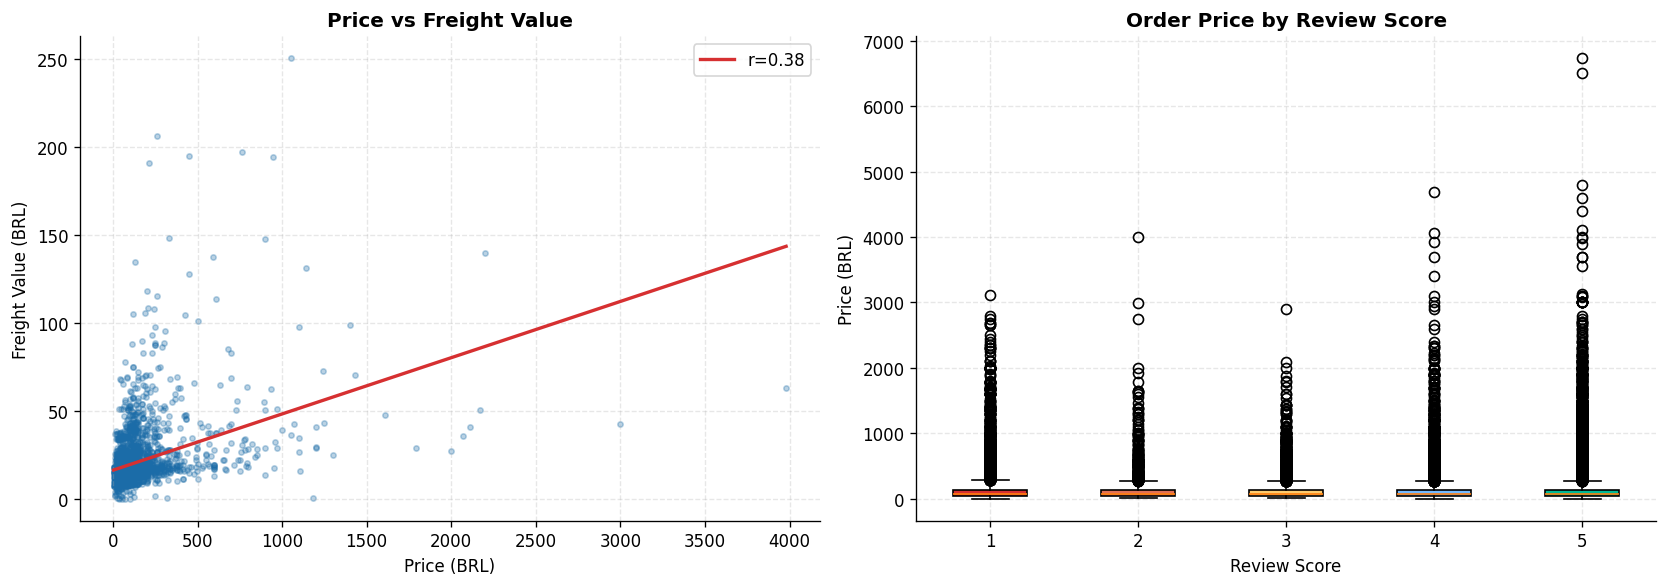

Regression equation: Freight = 0.032 × Price + 16.18
Pearson r = 0.384 → Weak positive correlation


In [6]:
# ─── 2. BIVARIATE: Price vs Freight + Review by Category ──────────────────
# WHY: Scatter reveals correlation between order value and shipping cost.
#      Box plots compare distributions across groups.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ─── Plot 2a: Scatter + Regression Line (Price vs Freight) ────────────────
# Sample 3000 rows to avoid overplotting (100k points would be a solid blob)
sample = df[['price', 'freight_value']].dropna().sample(3000, random_state=42)
# random_state=42 makes sampling reproducible (same 3000 rows every run)

axes[0].scatter(
    sample['price'],  # X-axis: order price
    sample['freight_value'],  # Y-axis: shipping cost
    alpha=0.3,  # Low opacity → overlapping points show density
    color='#1B6CA8',
    s=10,  # s = marker size in points² (small → less clutter)
)

# Compute regression: returns slope m, intercept b, correlation r, p-value, std_err
m, b, r, p, _ = stats.linregress(sample['price'], sample['freight_value'])
# m = slope (how much freight increases per R$1 increase in price)
# b = y-intercept (freight cost when price = 0)
# r = Pearson correlation coefficient (-1 to +1)
# p = p-value (< 0.05 means statistically significant)

# Draw the regression line: y = m*x + b
x_line = np.linspace(sample['price'].min(), sample['price'].max(), 100)
axes[0].plot(
    x_line,
    m * x_line + b,
    color='#D63031',
    lw=2,  # Red line, linewidth=2
    label=f'r={r:.2f}',
)  # Show r value (correlation) in legend

axes[0].legend()  # Display the label we set above
axes[0].set_xlabel('Price (BRL)')
axes[0].set_ylabel('Freight Value (BRL)')
axes[0].set_title('Price vs Freight Value', fontsize=12, fontweight='bold')

# ─── Plot 2b: Box Plots by Review Score ───────────────────────────────────
# Build a list: one array of prices per each review score (1, 2, 3, 4, 5)
review_data = [df[df['review_score'] == s]['price'].dropna() for s in range(1, 6)]
# list of 5 pd Series
# review_data[0] = all prices where review_score == 1
# review_data[4] = all prices where review_score == 5

bp = axes[1].boxplot(
    review_data,  # list of 5 pd Series
    patch_artist=True,  # Fill boxes with color
    labels=[1, 2, 3, 4, 5],  # X-axis tick labels
)

# Apply a color gradient on review groups: red (bad review) → yellow → green (good review)
colors = ['#D63031', '#E17055', '#FDCB6E', '#74B9FF', '#00B894']
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c)  # Color each box differently

axes[1].set_title('Order Price by Review Score', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Review Score')
axes[1].set_ylabel('Price (BRL)')

plt.tight_layout()
plt.savefig('olist_bivariate.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Regression equation: Freight = {m:.3f} × Price + {b:.2f}")
print(
    f"Pearson r = {r:.3f} → "
    f"{'Weak' if abs(r) < 0.4 else 'Moderate' if abs(r) < 0.7 else 'Strong'} "
    f"{'positive' if r > 0 else 'negative' if r < 0 else 'no'} correlation"
)

<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="font-weight:bold; font-size:1.15em;">

🔍 Code Walkthrough — Plot 2: Scatter + Box Plots</p>

<p style="font-weight:bold; font-size:1.15em;">

`.sample(3000, random_state=42)`</p>
Takes a random sample of 3000 rows from the DataFrame.  
- Needed to avoid **overplotting** (100k dots would form a solid blob)  
- `random_state=42` → same seed = reproducible results (anyone running the code gets identical results)

<p style="font-weight:bold; font-size:1.15em;">

`stats.linregress(x, y)`</p>
From `scipy.stats`. Fits a straight line `y = m*x + b` to the data.

| Return value | Symbol | Meaning |
|---|---|---|
| `slope` | `m` | How much y increases per unit of x |
| `intercept` | `b` | Value of y when x = 0 |
| `rvalue` | `r` | Pearson correlation coefficient |
| `pvalue` | `p` | Statistical significance (< 0.05 = significant) |
| `stderr` | `_` | Standard error of the slope (we discard with `_`) |

<p style="font-weight:bold; font-size:1.15em;">

`np.linspace(start, stop, num)`</p>
Creates `num` evenly-spaced values between `start` and `stop`.  
Used to generate the x-coordinates of the regression line.

<p style="font-weight:bold; font-size:1.15em;">

Building the list for `boxplot()`</p>
```python
review_data = [df[df['review_score']==s]['price'].dropna() for s in range(1,6)]
```
This is a **list comprehension** — it creates a list of 5 Series (one per star rating).  
`df[df['review_score']==s]` is **boolean indexing** — filters rows where review_score equals `s`.

<p style="font-weight:bold; font-size:1.15em;">

`zip(bp['boxes'], colors)`</p>
`bp['boxes']` is the list of box patches returned by `boxplot()`.  
`zip()` pairs each box with a color so we can loop and set `.set_facecolor(c)` on each.

</div>

<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

**How does `plt.boxplot()` know whether to draw one box or many?**

It depends on **what data you pass in** — specifically how many array-like objects (lists, Series, arrays) you provide.

---

**One boxplot — pass a single array-like:**
```python
plt.boxplot([10, 20, 15, 30, 25])
```
One array → one box.

---

**Multiple boxplots — pass a list of array-likes:**
```python
plt.boxplot([
    [10, 20, 15],          # group 1 — plain list
    pd.Series([30, 25]),   # group 2 — Series
    np.array([50, 45, 55]) # group 3 — numpy array
])
```
Each array-like → one box. Three of them → three boxes side by side.

---

**In your case (grouped by review score):**
```python
groups = [df[df['review_score'] == score]['price'] for score in [1,2,3,4,5]]
plt.boxplot(groups)
```
You're passing 5 Series (one per score) → matplotlib draws 5 boxes automatically.

---

**The rule is simple:**
> Number of boxes = number of array-likes passed in.

matplotlib counts them, places one box per array-like, and spaces them evenly on the x-axis — no extra configuration needed.

</div>

<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="font-weight:bold; font-size:1.15em;">💡 Insight — Bivariate Analysis</p>

**Freight cost increases with order price (positive correlation), but weakly (r ≈ 0.39)** — bulk/heavy items drive freight more than value.  
Higher-priced orders tend to get better reviews, but the relationship has high variance, suggesting **delivery experience matters too**. The variance is so high (because outliers everywhere, medians nearly equal) that price alone clearly doesn't explain the score.

</div>

<p style="color: steelblue; font-size: 1.5em;">💡 More Insights:</p>
<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

**Plot 1 — Price vs Freight Value (Scatter)**

- **Weak positive correlation (r = 0.38)** — as price increases, shipping cost tends to rise, but loosely
- Most orders cluster at **low price (0–500 BRL) and low freight (0–50 BRL)** — the bulk of business is cheap, light items
- **High variance at low prices** — freight can be anywhere from 0 to 200 BRL even for cheap items, suggesting size/weight matters more than price for shipping
- A few **extreme outliers** — items priced at 3000–4000 BRL but with relatively low freight, possibly digital or small luxury goods

---

**Plot 2 — Order Price by Review Score (Boxplot)**

- **Medians are nearly identical across all scores (1–5)** — price alone doesn't explain customer satisfaction
- **All boxes are extremely compressed near zero** with massive outliers above — meaning most orders are low-priced regardless of review score
- **Score 4 and 5 have the most extreme outliers** (up to ~4800 BRL) — high-value purchases still tend to get good reviews
- **Score 1 has notable high-value outliers too** — expensive items receiving bad reviews could indicate unmet expectations

---

**Key takeaway:**
> Price has little to no relationship with customer satisfaction, but heavier/larger items cost more to ship regardless of their price.
</div>

<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

## 5. Pattern Discovery: Time-Series & Seasonality

<div style=" border-left:5px solid #2E8B6E; padding:15px; border-radius:4px; margin:10px 0;">
<strong>Principle:</strong> With temporal data, always plot the time series first before any aggregation. Annotated line charts communicate findings to stakeholders effectively.
</div>

<p style="font-weight:bold; font-size:1.1em;">What is a Time-Series Line Chart?</p>

A **time-series chart** plots values over time along the x-axis. For business data:

- **Trend** = long-term direction (growth, decline, flat)
- **Seasonality** = recurring patterns (weekly, monthly, yearly)
- **Anomalies** = unexpected spikes or drops (Black Friday, COVID, etc.)

**Key techniques:**
- `fill_between()` fills the area under the line → visually emphasizes volume
- `annotate()` adds arrows pointing to key events → helps stakeholders understand *why* there's a spike

---

<p style="font-weight:bold; font-size:1.1em;">What is a Day-of-Week Bar Chart (Seasonality)?</p>

By grouping orders by **day of week** and computing the average order value, we can detect **weekly seasonality**:
- Are Monday orders more valuable than Sunday orders?
- Does purchase behavior follow work-week patterns?

We use `df['timestamp'].dt.day_name()` to extract the day name from a datetime column.

---
</div>

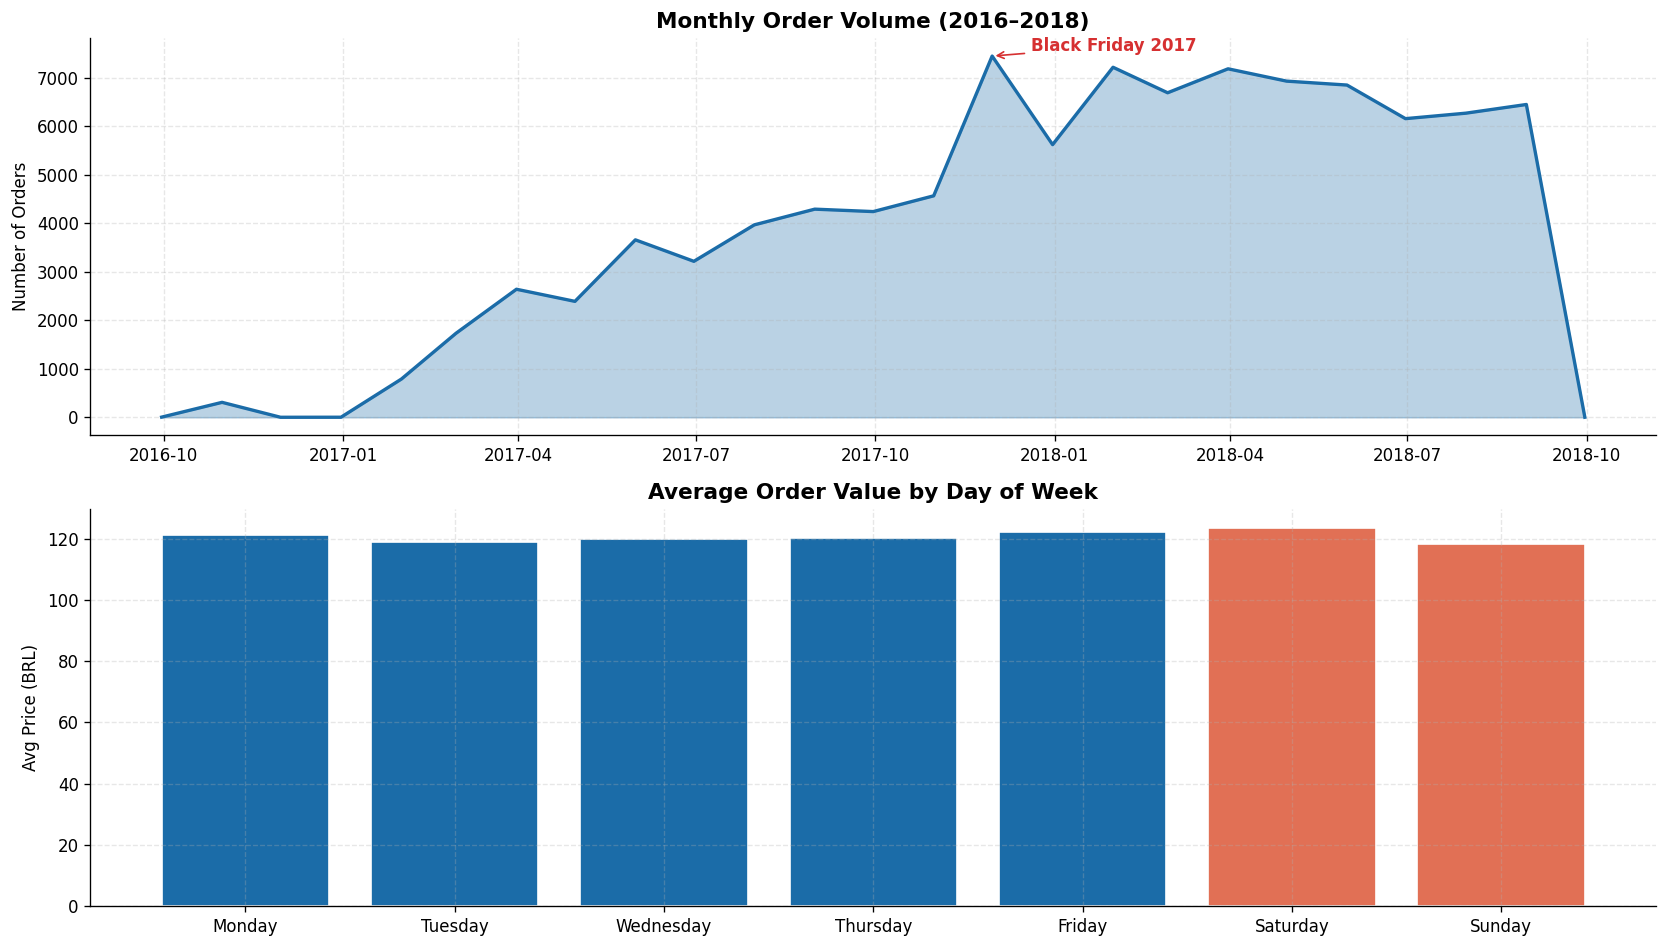

Peak month: November 2017 with 7,451 orders
Growth: 0.3x from start to end


In [7]:
# ─── 3. PATTERN DISCOVERY: Monthly Orders + Seasonality ───────────────────
# WHY: Time-series reveals the Nov 2017 Black Friday spike
#      and overall growth trend --- critical business insight.

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
# 2 rows, 1 column → top chart for monthly trend, bottom for day-of-week

# ─── Plot 3a: Monthly Order Volume Trend ──────────────────────────────────
# fill_between: shades the area between y=0 and the data line
axes[0].fill_between(
    monthly['month'],  # X-axis: datetime values
    monthly['order_count'],  # Y-axis: number of orders
    alpha=0.3,  # Light fill (mostly see the line)
    color='#1B6CA8',
)
# Plot the line on top of the fill
axes[0].plot(
    monthly['month'],
    monthly['order_count'],
    color='#1B6CA8',
    linewidth=2,  # Thicker line for the trend
)
axes[0].set_title('Monthly Order Volume (2016–2018)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Orders')

# ─── Annotate Black Friday 2017 ────────────────────────────────────────────
# Find the month with the maximum order count
# idxmax(): return the row label of the maximum value.
peak_month = monthly.loc[monthly['order_count'].idxmax(), 'month']
peak_val = monthly['order_count'].max()

axes[0].annotate(
    'Black Friday 2017',  # The text to display
    xy=(peak_month, peak_val),  # Arrow tip: points TO this location
    xytext=(
        peak_month + timedelta(days=20),
        peak_val + 100,
    ),  # Text location:  ABOVE the peak (+100) and shifted to RIGHT (by 10 days)
    arrowprops=dict(
        arrowstyle='->',  # Arrow style: '->' = simple arrow
        color='#D63031',  # Red arrow
    ),
    color='#D63031',  # Red text
    fontweight='bold',
)

# ─── Plot 3b: Day-of-Week Seasonality ─────────────────────────────────────
# Extract day name from the datetime column
# dow: day of week
df['dow'] = df['order_purchase_timestamp'].dt.day_name()
# dt.day_name() → 'Monday', 'Tuesday', ... 'Sunday'

# Reindex to enforce correct Mon→Sun order (groupby sorts alphabetically otherwise)
dow_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday',
]
dow_avg = df.groupby('dow')['price'].mean().reindex(dow_order)
# groupby('dow') → groups rows by day name
# ['price'].mean() → average price per group
# .reindex(dow_order) → reorders from Mon→Sun

# Color weekdays blue, weekends orange
colors = ['#1B6CA8'] * 5 + ['#E17055'] * 2

axes[1].bar(
    dow_avg.index,  # X-axis: day names
    dow_avg.values,  # Y-axis: average order value
    color=colors,
    edgecolor='white',
)
axes[1].set_title('Average Order Value by Day of Week', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Avg Price (BRL)')

plt.tight_layout()
plt.savefig('olist_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Peak month: {peak_month.strftime('%B %Y')} with {peak_val:,} orders")
print(
    f"Growth: {monthly['order_count'].iloc[-1] / monthly['order_count'].iloc[0]:.1f}x from start to end"
)

<div style="max-width: 900px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="font-weight:bold; font-size:1.15em;">

🔍 Code Walkthrough — Plot 3: Time-Series & Seasonality</p>

<p style="font-weight:bold; font-size:1em;">

`axes[0].fill_between(x, y, alpha=..., color=...)`</p>
Fills the area between the x-axis (y=0) and the data line.  
- Creates an **area chart** effect that emphasizes volume visually  
- `alpha=0.3` makes it translucent so the grid lines show through

<p style="font-weight:bold; font-size:1em;">

`ax.annotate(text, xy=..., xytext=..., arrowprops=...)`</p>
Adds a text annotation with an optional arrow.

| Parameter | Meaning |
|---|---|
| `text` | The string to display |
| `xy=(x, y)` | Where the **arrow tip** points (the thing you're annotating) |
| `xytext=(x, y)` | Where the **text** appears (different from arrow tip) |
| `arrowprops=dict(arrowstyle='->', color='red')` | Arrow style and color |

<p style="font-weight:bold; font-size:1em;">

`monthly['order_count'].idxmax()`</p>
Returns the **index** of the maximum value — here, the row number of the peak month.  
Then `monthly.loc[idx, 'month']` retrieves the actual month value at that row.

<p style="font-weight:bold; font-size:1em;">

`.dt.day_name()`</p>
Pandas datetime accessor. Works only on datetime Series (after `pd.to_datetime()`).  
Returns strings: `'Monday'`, `'Tuesday'`, ... `'Sunday'`.

<p style="font-weight:bold; font-size:1em;">

`.groupby('dow')['price'].mean()`</p>
- `.groupby('col')` → splits the DataFrame into groups by unique values of `'col'`
- `['price']` → selects only the price column within each group
- `.mean()` → computes average per group  
- Result: a Series with day names as index and average prices as values

<p style="font-weight:bold; font-size:1em;">

`.reindex(dow_order)`</p>
Forces the Series/DataFrame to match the order given.  
Crucial here because `groupby` sorts alphabetically (Friday, Monday, Saturday...) not by weekday order.

</div>

<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7; margin-top:10px;">

</div>

<p style="color: steelblue; font-size: 1.5em;">💡 Insights:</p>
<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

**Plot 1 — Monthly Order Volume (2016–2018)**

- **Strong overall growth** — orders grew from near zero in late 2016 to ~7000/month by early 2018, suggesting the business was scaling rapidly
- **Black Friday 2017 spike** — a sharp peak in Nov 2017 (~7500 orders), the highest single month, driven by seasonal shopping
- **Dip after Black Friday** — Dec 2017 dropped noticeably, likely a post-event slowdown, then recovered
- **Plateau in 2018** — growth flattened between 6000–7000 orders from Jan–Aug 2018, suggesting market saturation or slower acquisition
- **Sharp cliff at Oct 2018** — orders drop to near zero, almost certainly **incomplete data** for that month, not a real business collapse

---

**Plot 2 — Average Order Value by Day of Week**

- **Remarkably flat across all days** — all bars sit between ~118–124 BRL, meaning customers spend roughly the same amount regardless of the day
- **Weekends (Saturday, Sunday) are slightly higher** — Saturday peaks at ~123 BRL, suggesting weekend shoppers may buy slightly more premium items
- **No strong weekday effect** — unlike many e-commerce platforms, there's no "Monday motivation" or "Friday splurge" pattern here

---

**Key takeaway:**
> The business grew aggressively through 2017, peaked on Black Friday, then stabilized — but customer spending behavior is highly consistent regardless of the day, meaning promotions targeting specific days would likely have limited impact.

</div>

<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

## 6. Multivariate Analysis

<div style=" border-left:5px solid #2E8B6E; padding:15px; border-radius:4px; margin:10px 0;">
<strong>Goal:</strong> Study three or more variables simultaneously to capture complex interdependencies. We use a correlation heatmap (all pairwise) and a bubble chart (4 variables in one plot).
</div>

<p style="font-weight:bold; font-size:1.1em;">What is a Correlation Heatmap?</p>

A **correlation matrix** shows the **Pearson correlation coefficient (r)** between every pair of numeric variables. Each cell contains a value from −1 to +1:

- **r = +1** → perfect positive linear relationship (as x grows, y grows proportionally)
- **r = 0** → no linear relationship
- **r = −1** → perfect negative linear relationship (as x grows, y shrinks proportionally)

**Why mask the upper triangle?**  
A correlation matrix is symmetric: `corr(A, B) == corr(B, A)`. Showing both triangles is redundant. `np.triu()` creates a mask for the upper triangle so we only show the lower half — cleaner and easier to read.

**Diverging colormap:** We use `'RdBu_r'` (Red-Blue reversed):
- **Deep blue** → strong negative correlation (e.g., fast delivery → high review score)
- **White** → no correlation (r ≈ 0)
- **Deep red** → strong positive correlation

---

<p style="font-weight:bold; font-size:1.1em;">What is a Bubble Chart?</p>

A bubble chart extends a scatter plot to encode **4 variables simultaneously**:

| Dimension | Variable |
|---|---|
| **X-axis** | price |
| **Y-axis** | freight_value |
| **Bubble size (s)** | delivery_days (larger bubble = slower delivery) |
| **Bubble color (c)** | review_score (red = bad, green = good) |

This is powerful for identifying *patterns across multiple dimensions at once* — something impossible with 2D plots alone.

---
</div>

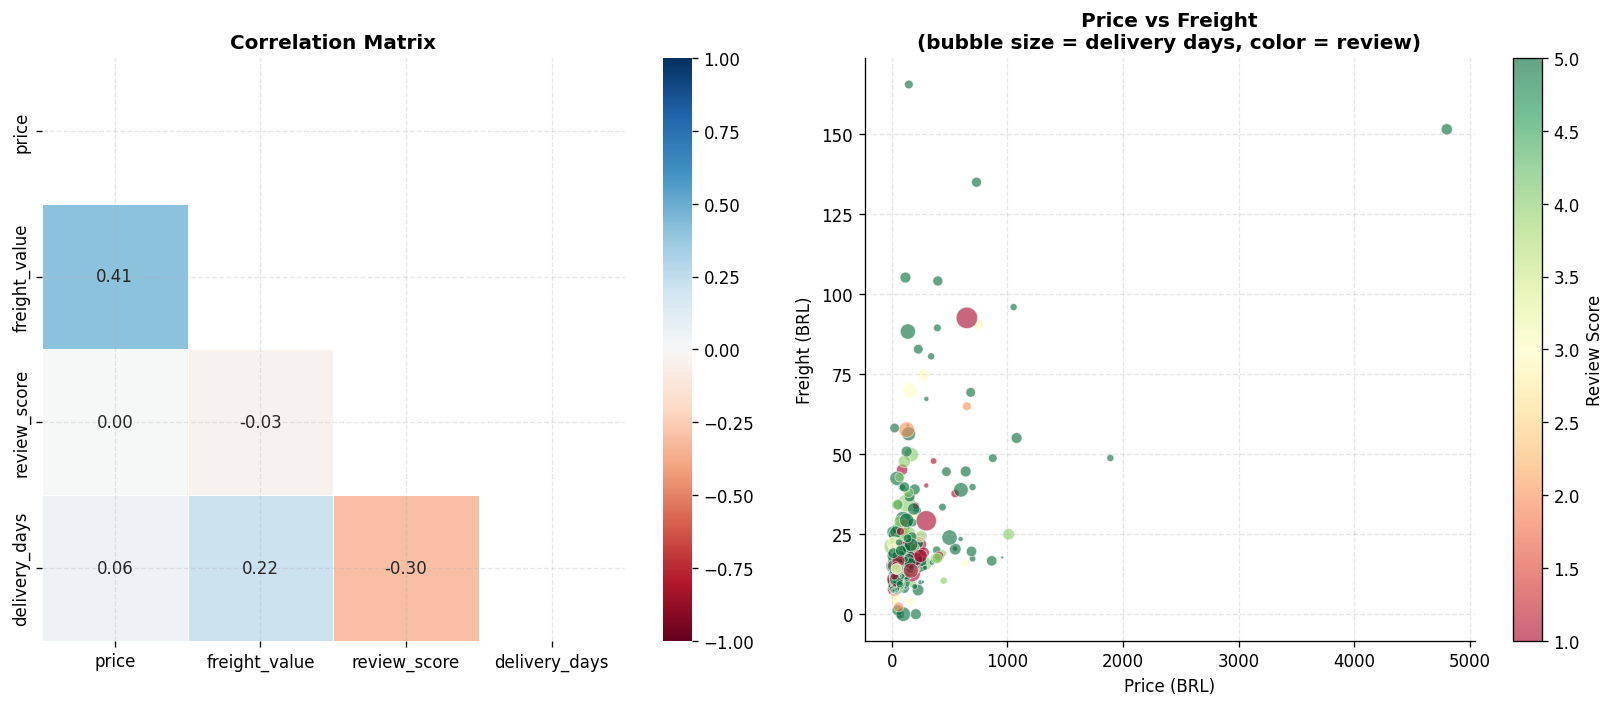

Key correlations with review_score:
delivery_days   -0.304058
freight_value   -0.032863
price            0.003259
Name: review_score, dtype: float64


In [8]:
# ─── 4. MULTIVARIATE: Correlation Heatmap + Bubble Chart ──────────────────
# WHY: Correlation matrix flags multicollinearity before modeling.
#      Bubble chart encodes 4 variables simultaneously.

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ─── Plot 4a: Correlation Heatmap ─────────────────────────────────────────
num_cols = ['price', 'freight_value', 'review_score', 'delivery_days']
corr = df[num_cols].dropna().corr()
# .corr() computes the Pearson correlation matrix — result is a 4×4 DataFrame
# Each cell [i,j] = Pearson r between column i and column j

# Create a mask for the upper triangle (True = masked/hidden)
mask = np.triu(np.ones_like(corr, dtype=bool))
# np.ones_like(corr) → 4×4 matrix of ones (same shape as corr)
# np.triu() → keeps upper triangle as True, lower as False
# dtype=bool → convert to boolean (True/False)

sns.heatmap(
    corr,
    ax=axes[0],
    annot=True,  # Show the r value in each cell
    fmt='.2f',  # Format: 2 decimal places (e.g., 0.39)
    mask=mask,  # Hide the upper triangle (it's redundant) --> True means mask out
    cmap='RdBu',  # Red-Blue reversed: red=positive, blue=negative
    center=0,  # 0 correlation = white (neutral)
    vmin=-1,
    vmax=1,  # Fix scale from -1 to +1
    square=True,  # Force square cells
    linewidths=0.5,  # Thin lines between cells for visual separation
)
axes[0].set_title('Correlation Matrix', fontsize=12, fontweight='bold')

# ─── Plot 4b: Bubble Chart ────────────────────────────────────────────────
# Sample 500 points (scatter with all 100k would be unreadable)
sample2 = df[num_cols].dropna().sample(500, random_state=42)

scatter = axes[1].scatter(
    sample2['price'],  # X-axis: order price
    sample2['freight_value'],  # Y-axis: freight cost
    s=sample2['delivery_days'].clip(1, 60) * 3,
    # s = bubble size: delivery_days × 3 (scale up for visibility)
    # .clip(1, 60) caps extreme values (prevents enormous bubbles)
    c=sample2['review_score'],  # c = color: review score 1–5
    cmap='RdYlGn',  # Red (bad) → Yellow → Green (good)
    alpha=0.6,  # Semi-transparent bubbles
    edgecolors='white',  # White outline for visual separation
    linewidth=0.5,
)
# Add a colorbar to decode the color scale
plt.colorbar(scatter, ax=axes[1], label='Review Score')

axes[1].set_xlabel('Price (BRL)')
axes[1].set_ylabel('Freight (BRL)')
axes[1].set_title(
    'Price vs Freight\n(bubble size = delivery days, color = review)',
    fontsize=12,
    fontweight='bold',
)

plt.tight_layout()
plt.savefig('olist_multivariate.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── Print key correlations ────────────────────────────────────────────────
print("Key correlations with review_score:")
print(corr['review_score'].drop('review_score').sort_values())

<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

<p style="font-weight:bold; font-size:1.15em;">

🔍 Code Walkthrough — Plot 4: Correlation Heatmap + Bubble Chart</p>

<p style="font-weight:bold; font-size:1.15em;">

`df[num_cols].dropna().corr()`</p>
- `.dropna()` removes rows with any NaN in these 4 columns
- `.corr()` computes a pairwise Pearson correlation matrix (DataFrame of shape 4×4)
- **Default:** Pearson. Use `method='spearman'` for rank-based or `method='kendall'` for ordinal data

<p style="font-weight:bold; font-size:1.15em;">

`np.triu(np.ones_like(corr, dtype=bool))`</p>
- `np.ones_like(corr)` → creates a matrix of 1s with the same shape as `corr`
- `np.triu()` → keeps upper triangle as 1, sets lower to 0
- `dtype=bool` → convert to True/False for the mask

<p style="font-weight:bold; font-size:1.15em;">

`sns.heatmap(...)`</p>

| Parameter | Meaning | Example |
|---|---|---|
| `annot=True` | Write numbers in each cell | `True` / `False` |
| `fmt='.2f'` | Number format string | `'.2f'` = 2 decimals, `'d'` = integer |
| `mask=mask` | Boolean array — True cells are hidden | Upper triangle mask |
| `cmap='RdBu_r'` | Color map name | Any matplotlib colormap |
| `center=0` | Value mapped to center color (white) | `0` for correlations |
| `vmin` / `vmax` | Color scale limits | `-1` to `+1` for correlations |
| `square=True` | Force square cell aspect ratio | `True` / `False` |
| `linewidths` | Grid line thickness between cells | `0.5` |

<p style="font-weight:bold; font-size:1.15em;">

`ax.scatter(..., s=..., c=..., cmap=...)`</p>
Encoding 4 variables in scatter:
- `s` = marker size (must be **positive** — use `.clip(1, 60)` to avoid zero sizes)
- `c` = color value — can be a numeric array (mapped via `cmap`)
- `cmap='RdYlGn'` = Red → Yellow → Green (diverging: bad → neutral → good)
- `plt.colorbar(scatter, ax=axes[1])` adds the legend showing what colors mean

</div>

<p style="color: steelblue; font-size: 1.5em;">More on heatmap():</p>
<div style="max-width: 900px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

**`corr`** — the correlation matrix DataFrame passed as the data, where each cell is the Pearson r between two variables.

---

**`annot=True`** — prints the r value inside each cell so you can read exact numbers, not just colors.

---

**`fmt='.2f'`** — formats those numbers to 2 decimal places. Without this, you'd get long floats like `0.38734...`

---

**`mask=mask`** — hides cells where mask is `True`. Typically the upper triangle is masked because it's a mirror of the lower triangle — showing both is redundant.

---

**`cmap='RdBu_r'`** — the colormap. Controls what colors map to what values.

Common options for correlation heatmaps:

| cmap | Colors | Good for |
|---|---|---|
| `'RdBu'` | blue=positive, red=negative | correlation (default direction) |
| `'RdBu_r'` | red=positive, blue=negative | correlation (reversed — more intuitive) |
| `'RdYlGn'` | red → yellow → green | performance, scores |
| `'RdYlGn_r'` | green → yellow → red | risk, errors |
| `'coolwarm'` | blue → white → red | similar to RdBu_r, softer |
| `'PiYG'` | pink → light yellow like white → green | diverging, colorblind-friendly |
| `'seismic'` | blue → white → red | high contrast diverging |

**What does `_r` (reversed) mean?**
Every matplotlib colormap has a reversed version — just append `_r` to flip the color direction end-to-end.

**Red-Green reversed (`RdYlGn_r`):**
```python
sns.heatmap(corr, cmap='RdYlGn_r', center=0, vmin=-1, vmax=1)
# green=negative, red=positive
# ⚠ avoid if your audience may be red-green colorblind
```

**Better colorblind-safe alternative:**
```python
sns.heatmap(corr, cmap='PiYG', center=0, vmin=-1, vmax=1)
# pink → white → green — distinguishable for most colorblindness types
```

---

**`center=0`** — tells seaborn that 0 is the neutral midpoint, so white lands exactly at zero correlation. Without this, white might not align with 0.

---

**`vmin=-1, vmax=1`** — fixes the color scale to the full possible range of correlation. Without this, the scale auto-fits to your data range and colors become misleading — a weak `0.3` might look strongly red if it's the max in your data.

---

**`square=True`** — forces each cell to be square instead of rectangular, making the heatmap easier to read visually.

---

**`linewidths=0.5`** — draws thin grid lines between cells so adjacent values don't bleed into each other visually.

</div>

<p style="color: steelblue; font-size: 1.5em;">💡 Insights:</p>
<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

**Plot 1 — Correlation Matrix**

- **Price ↔ Freight (0.41)** — the strongest relationship here: heavier/bulkier items cost more to ship and tend to be priced higher, a moderate and expected link
- **Review ↔ Price (0.00)** — essentially zero, confirming what we saw earlier: how much you pay has no bearing on how satisfied you are
- **Review ↔ Freight (-0.03)** — also near zero, shipping cost alone doesn't drive satisfaction either
- **Delivery days ↔ Review (-0.30)** — the most actionable insight: longer delivery → lower review score, a weak-to-moderate negative relationship suggesting delivery speed genuinely affects satisfaction
- **Delivery days ↔ Freight (0.22)** — orders that take longer also tend to cost more to ship, possibly because they are going to remote or far destinations

---

**Plot 2 — Price vs Freight Bubble Chart**

- **Most orders cluster bottom-left** — the vast majority are low price (0–500 BRL) and low freight (0–50 BRL), consistent with the earlier scatter plot
- **Green dominates the cluster** — most orders in the dense region have review scores of 4–5, suggesting that typical, affordable orders generally satisfy customers
- **Red/pink bubbles appear in the mid-freight range** — unhappy customers (score 1–2) tend to cluster around moderate freight costs (25–75 BRL), possibly reflecting unmet delivery expectations, like a big red bubble in the middle which means long delivery period
- **Large bubbles (long delivery) are mixed in color** — some long-delivery orders get good reviews, some get bad ones, meaning delivery time alone doesn't fully determine satisfaction
- **High-price outliers (3000–5000 BRL) are green** — expensive orders in this sample appear to have satisfied customers, echoing the near-zero price-review correlation

---

**Key takeaway:**
> Delivery speed is the clearest lever for improving customer satisfaction — not price, not freight cost. Faster delivery = better reviews, and that signal is consistent across both plots.

</div>

<div style="max-width: 800px; border-left:3px solid steelblue; padding:15px; border-radius:3px; font-family: 'Anthropic Sans', sans-serif; font-size: 16px; line-height: 1.7;">

## 7. Dashboard Design & Implementation

---

<p style="font-weight:bold; font-size:1.1em;">📊 What is a Dashboard?</p>

> *"A dashboard is a visual display of the most important information needed to achieve one or more objectives, consolidated and arranged on a single screen so the information can be monitored at a glance."*  
> — Stephen Few, *Information Dashboard Design*

A dashboard translates raw data into **actionable insights** for a specific audience. Unlike exploratory analysis (which is for the analyst), a dashboard is for **decision-makers who don't have time to run queries**.

---

<p style="font-weight:bold; font-size:1.1em;">Dashboard Design Principles</p>

<p style="font-weight:bold; font-size:1.1em;">✅ Good Practices</p>

| Principle | Implementation |
|---|---|
| **5-Second Rule** | The key message should be readable in 5 seconds. Test: show to someone for 5 seconds, ask "what's the main message?" |
| **Limit to 5–7 panels** | More panels = cognitive overload. Every panel must earn its place |
| **KPI cards at the top** | Always lead with 3–4 key metrics. Viewers read top-to-bottom |
| **Consistent color convention** | Pick one color for "good", one for "bad", use them throughout |
| **Clear labels and units** | Never make the viewer guess what the y-axis measures |
| **Pre-calculated metrics** | Show R$ 137 avg, not raw data the viewer must calculate |

<p style="font-weight:bold; font-size:1.1em;">❌ Bad Practices</p>

| Avoid | Why |
|---|---|
| 3D charts | Distort proportions; never add information |
| Pie charts with many slices | Hard to compare slice sizes |
| Inconsistent colors (red = bad in panel 1, red = good in panel 2) | Confuses viewers |
| Decorations and "chart junk" | Removes focus from data |
| Too many panels | Viewer can't identify the key message |

---

<p style="font-weight:bold; font-size:1.1em;">Understanding Matplotlib's Grid Layout for Dashboards</p>

<p style="font-weight:bold; font-size:1.1em;">Creating a Custom Grid with `GridSpec`</p>

`plt.subplots(rows, cols)` gives equal-sized panels. For dashboards, we need **panels of different sizes**. That's where `GridSpec` comes in:

```python
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(
    nrows=3,    # 3 rows
    ncols=3,    # 3 columns
    figure=fig,
    hspace=0.5,    # Vertical space between rows (fraction of avg axis height)
    wspace=0.4,    # Horizontal space between columns
    left=0.07,     # Left margin (fraction of figure width)
    right=0.97,    # Right margin
    top=0.88,      # Top margin (leaves room for title)
    bottom=0.07    # Bottom margin
)

# Add subplots at specific grid positions
ax_top_left   = fig.add_subplot(gs[0, 0])    # row 0, col 0
ax_top_right  = fig.add_subplot(gs[0, 1:3])  # row 0, cols 1–2 (wide panel!)
ax_full_width = fig.add_subplot(gs[1, :])    # row 1, all 3 cols
```

**Slicing the grid** — just like NumPy array slicing:
- `gs[row, col]` → single cell
- `gs[row, col1:col2]` → span multiple columns
- `gs[row1:row2, col]` → span multiple rows

---

<p style="font-weight:bold; font-size:1.1em;">Our Dashboard Design Brief</p>

**Story:** *"What drives customer satisfaction on Olist?"*  
**Audience:** Operations & Customer Experience Manager

| Panel | Content | Plot Type |
|---|---|---|
| KPI Row (top, 4 cards) | Avg Review Score \| Avg Delivery Days \| Total Orders \| Revenue | Metric Cards |
| Main Chart (wide) | Monthly order volume with trend & Black Friday annotation | Line Chart |
| Middle Left | Review score distribution | Bar Chart |
| Middle Right | Delivery days vs review score (scatter) | Scatter Plot |
| Bottom Left | Price distribution histogram | Histogram |
| Bottom Right | Orders by day of week | Bar Chart |

**Color convention:**
- 🔴 **Red** → Low ratings, bad delivery performance
- 🟢 **Green** → High ratings, good performance
- 🔵 **Blue** → Neutral information (orders, prices)

---
</div>

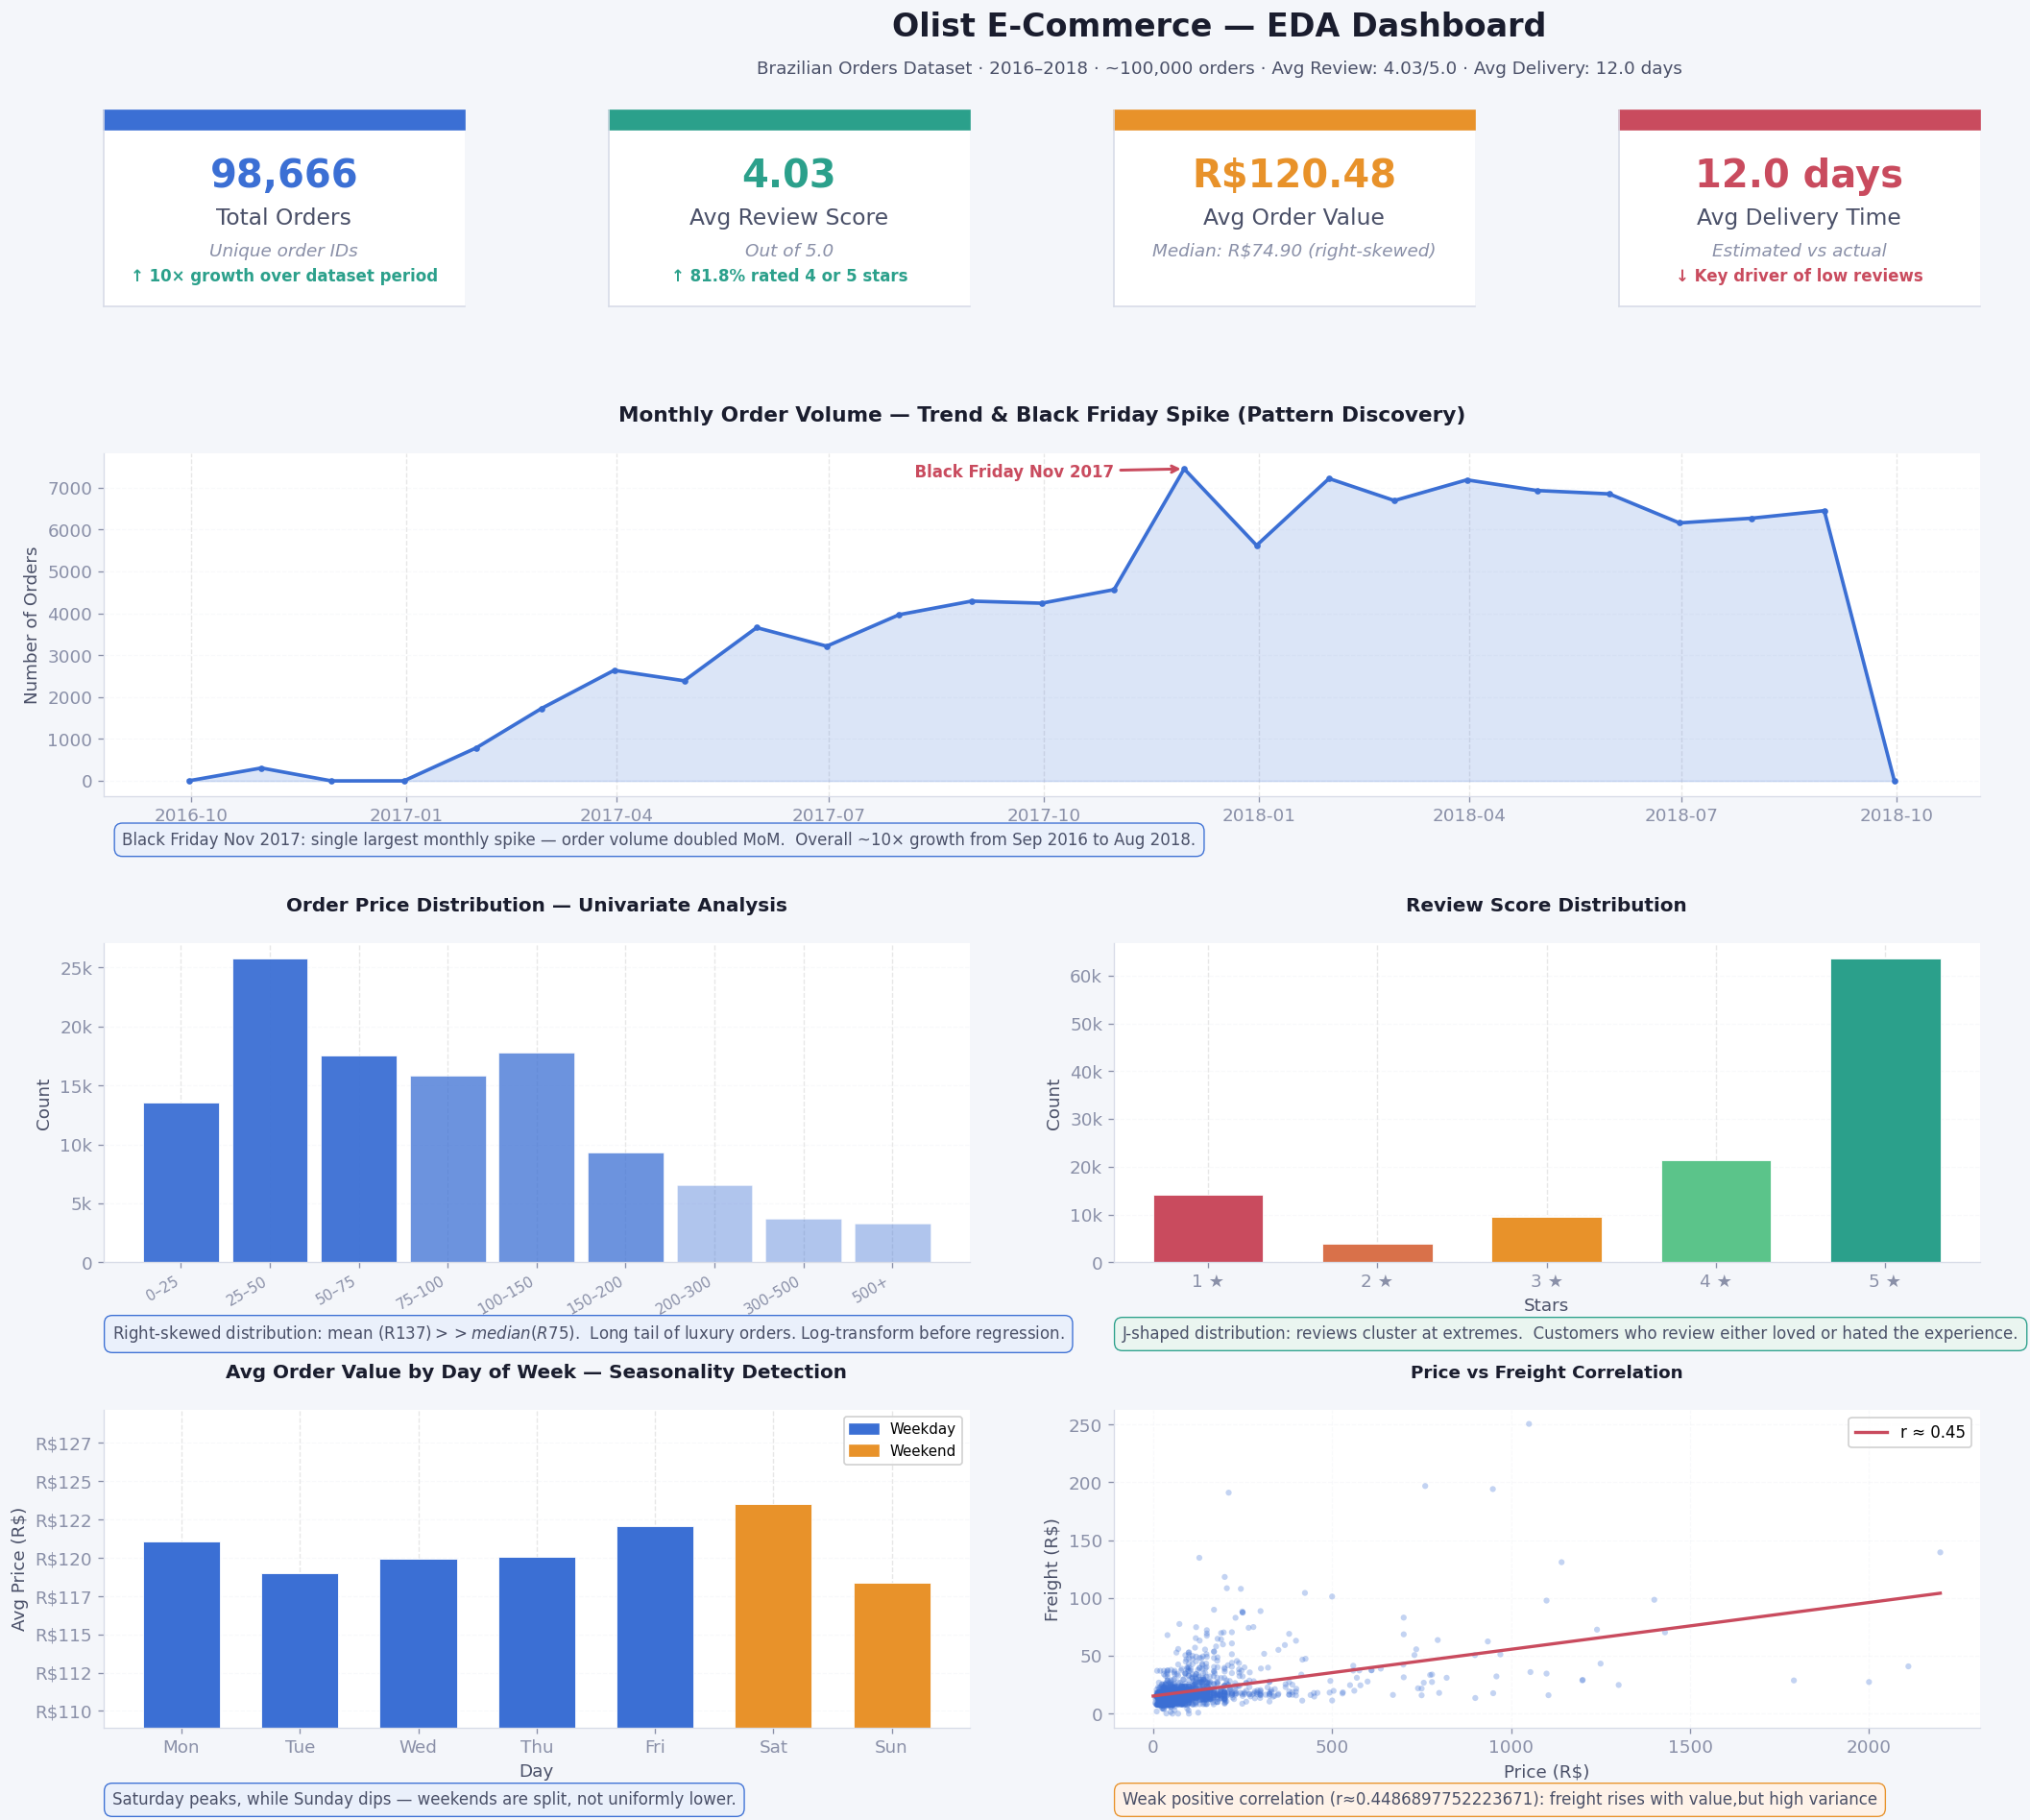

✅ Dashboard saved as olist_dashboard_light.png


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# DASHBOARD — Olist E-Commerce EDA Summary  (Light Theme)
# Story: "What drives customer satisfaction on Olist?"
# Audience: Operations & Customer Experience Manager
#
# Layout:
#   Row 0 — 4 KPI cards (Total Orders | Avg Review | Avg Order Value | Avg Delivery)
#   Row 1 — Full-width line chart: Monthly Order Volume + Black Friday annotation
#   Row 2 — Left: Price histogram  |  Right: Review score bar chart
#   Row 3 — Left: Avg Order Value by Day of Week bar  |  Right: Price vs Freight scatter
# ════════════════════════════════════════════════════════════════════════════

import matplotlib.gridspec as gridspec  # gridspec: fine-grained subplot layout (rows/cols with custom sizes)
import matplotlib.patches as mpatches  # mpatches: drawing shapes (Rectangle, Patch) directly on axes

# ── Color palette (light theme) ───────────────────────────────────────────
ACCENT_BLUE = '#3B6FD4'  # primary accent — orders, neutral info
ACCENT_GREEN = '#2BA08B'  # positive / high ratings
ACCENT_ORANGE = '#E8922A'  # order value / weekends
ACCENT_RED = '#C94B5E'  # negative / low ratings / delivery time
CARD_BG = '#FFFFFF'  # white card background
CANVAS_BG = '#F4F6FA'  # light grey figure background
BORDER_CLR = '#D8DCE8'  # card border colour
TEXT_DARK = '#1A1D2E'  # headings
TEXT_MID = '#4A5068'  # labels
TEXT_MUTED = '#8A90A8'  # sub-labels, axis ticks
GRID_CLR = '#EAECF4'  # chart grid lines


# ─────────────────────────────────────────────────────────────────────────
# HELPER: apply common axis styling shared by all chart panels
# ─────────────────────────────────────────────────────────────────────────
def style_axis(ax, title, ylabel, xlabel='', xgrid=False):
    """
    Applies consistent spine, grid, tick, and title styling to a chart axis.

    Parameters
    ----------
    ax      : Axes  – the subplot to style
    title   : str   – chart title text
    ylabel  : str   – y-axis label
    xlabel  : str   – x-axis label (default empty string)
    xgrid   : bool  – whether to also show vertical (x-axis) grid lines (default False)

    Returns : None  – modifies ax in place
    """
    ax.set_facecolor(CARD_BG)  # white background for the chart area
    ax.set_title(
        title,  # chart title string
        fontsize=12,  # font size for the title text
        fontweight='bold',  # bold weight for emphasis
        color=TEXT_DARK,  # dark color for high contrast headings
        # pad: spacing in points between the chart top edge and the title text
        pad=20,
    )
    ax.set_ylabel(
        ylabel,  # y-axis label string
        color=TEXT_MID,  # medium grey — less prominent than chart content
    )
    ax.set_xlabel(
        xlabel,  # x-axis label string (empty by default)
        color=TEXT_MID,  # medium grey — less prominent than chart content
    )
    # tick_params: style the axis tick labels — muted grey color
    ax.tick_params(colors=TEXT_MUTED)
    ax.spines['top'].set_visible(False)  # hide top border line — cleaner look
    ax.spines['right'].set_visible(False)  # hide right border line
    for sp in ['left', 'bottom']:
        ax.spines[sp].set_color(
            BORDER_CLR
        )  # keep left/bottom borders but soften their color
    ax.yaxis.grid(
        True,  # enable horizontal grid lines
        color=GRID_CLR,  # light grey grid color — subtle, not distracting
        linewidth=0.7,  # thin grid lines
        # zorder=0 puts them behind the chart elements
        zorder=0,
    )
    if xgrid:
        ax.xaxis.grid(
            True,  # enable vertical grid lines
            color=GRID_CLR,  # same subtle grey as horizontal grid
            linewidth=0.7,  # thin grid lines
            # zorder=0: vertical grid lines render behind chart elements
            zorder=0,
        )
    ax.set_axisbelow(True)  # ensure grid lines render below bars/lines, not on top


# ─────────────────────────────────────────────────────────────────────────
# HELPER: draw an insight text box below a chart panel
# ─────────────────────────────────────────────────────────────────────────
def insight_box(ax, text, facecolor, edgecolor, y=-0.24, fontsize=10):
    """
    Draws a rounded text box below the given axis to display an insight.

    Parameters
    ----------
    ax         : Axes  – the subplot to attach the text to
    text       : str   – insight text to display
    facecolor  : str   – background color of the box
    edgecolor  : str   – border color of the box
    y          : float – vertical position in axes coords (default -0.24, below the axis)
    fontsize   : int   – font size of the insight text (default 10)

    Returns    : None  – draws directly onto ax
    """
    ax.text(
        # position: just left of center, below the axes bottom edge
        0.01,  # x: 1% from left edge in axes coords
        y,  # y: below the axis (negative = outside the axes boundary)
        text,  # insight string to display inside the box
        transform=ax.transAxes,  # axes coords so it stays fixed relative to the chart
        fontsize=fontsize,  # font size passed in by caller
        color=TEXT_MID,  # medium grey text — readable but not dominant
        bbox=dict(  # bbox: draws a box around the text
            # rounded corners with 0.5 units of internal padding
            boxstyle='round,pad=0.5',
            facecolor=facecolor,  # background color for the insight box
            edgecolor=edgecolor,  # border color matching the chart accent
            lw=0.8,  # border line width
        ),
    )


# ─────────────────────────────────────────────────────────────────────────
# HELPER: apply common bar chart formatting (ticks, formatter, spines)
# ─────────────────────────────────────────────────────────────────────────
def format_yaxis_thousands(ax):
    """
    Applies a thousands formatter to the y-axis (e.g. 20000 → '20k').

    Parameters
    ----------
    ax  : Axes  – the subplot whose y-axis to format

    Returns : None  – modifies ax in place
    """
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda v, _: f'{int(v/1000)}k' if v >= 1000 else str(int(v)))
        # FuncFormatter: custom y-axis tick label function
        # lambda v, _: v=tick value, _=tick position (ignored)
        # if value ≥ 1000 → show as "20k"; otherwise show as plain integer
    )


# ── Figure Setup ──────────────────────────────────────────────────────────
fig = plt.figure(
    # figsize=(width, height) in inches — large canvas for dashboard
    figsize=(22, 18),
)
# set the outer figure background (behind all subplots) to light grey
fig.patch.set_facecolor(CANVAS_BG)
# global defaults: base font size and family for all text in the figure
plt.rcParams.update({'font.size': 11, 'font.family': 'sans-serif'})

# ── Custom Grid Layout ─────────────────────────────────────────────────────
# Row 0 : 4 equal KPI cards
# Row 1 : 1 wide main chart (all 4 cols)
# Row 2 : price histogram (2 cols) | review bar (2 cols)
# Row 3 : day-of-week bar (2 cols) | price-vs-freight scatter (2 cols)
gs = gridspec.GridSpec(
    # nrows: 4 horizontal bands (KPIs / main chart / row2 / row3)
    4,
    # ncols: 4 vertical columns — KPI cards each take 1
    4,
    figure=fig,  # attach this grid to our figure
    hspace=0.5,  # vertical space between rows (fraction of avg row height)
    wspace=0.40,  # horizontal space between columns (fraction of avg col width)
    left=0.06,  # left margin of the entire grid (fraction of figure width)
    right=0.80,  # right margin of the entire grid
    top=0.88,  # top margin — leaves room for the main title above
    bottom=0.1,  # bottom margin — leaves room for insight text boxes below charts
    # relative heights per row: KPI cards are shorter, main chart is tallest
    height_ratios=[0.8, 1.4, 1.3, 1.3],
)

# Each add_subplot(gs[row, col]) carves out a subplot at that grid position
ax_kpi1 = fig.add_subplot(gs[0, 0])  # row 0, col 0 → first KPI card
ax_kpi2 = fig.add_subplot(gs[0, 1])  # row 0, col 1 → second KPI card
ax_kpi3 = fig.add_subplot(gs[0, 2])  # row 0, col 2 → third KPI card
ax_kpi4 = fig.add_subplot(gs[0, 3])  # row 0, col 3 → fourth KPI card
ax_main = fig.add_subplot(gs[1, :])  # row 1, all cols (:) → full-width main line chart
ax_price = fig.add_subplot(gs[2, 0:2])  # row 2, cols 0–1 → left half: price histogram
ax_review = fig.add_subplot(
    gs[2, 2:4]
)  # row 2, cols 2–3 → right half: review bar chart
ax_dow = fig.add_subplot(gs[3, 0:2])  # row 3, cols 0–1 → bottom left: day-of-week bar
ax_scat = fig.add_subplot(gs[3, 2:4])  # row 3, cols 2–3 → bottom right: scatter plot


# ─────────────────────────────────────────────────────────────────────────
# HELPER: draw a styled KPI card
# ─────────────────────────────────────────────────────────────────────────
def kpi_card(ax, value, label, sub, accent, delta=None, delta_up=True):
    """
    Renders a KPI metric card on *ax*.

    Parameters
    ----------
    ax        : Axes   – subplot to draw on
    value     : str    – large headline number (e.g. "4.09")
    label     : str    – short descriptor under the number
    sub       : str    – small italic sub-text
    accent    : str    – hex colour used for the top bar and headline
    delta     : str    – optional trend line (e.g. "↑ 10× growth")
    delta_up  : bool   – True → green delta text; False → red

    Returns   : None   – draws directly onto ax, no return value
    """
    ax.set_facecolor(CARD_BG)  # white card background
    ax.set_xticks([])  # remove x-axis tick marks — cards have no data axis
    ax.set_yticks([])  # remove y-axis tick marks

    # ax.spines: dict of the 4 border lines (top/bottom/left/right)
    for sp in ax.spines.values():
        sp.set_edgecolor(BORDER_CLR)  # set border colour to light grey
        sp.set_linewidth(1)  # thin border line

    # Headline value — large bold number in accent color
    ax.text(
        # (x, y) in axes coordinates: 0.0=left/bottom, 1.0=right/top — centered horizontally, upper third
        0.5,  # x: centered horizontally
        0.66,  # y: upper third of the card
        value,  # the formatted string e.g. "96,096" or "R$137.75"
        # transAxes: coordinates are fractions of the axes (0–1), not data units
        transform=ax.transAxes,
        ha='center',  # horizontal alignment: center the text on x=0.5
        va='center',  # vertical alignment: center the text on y=0.66
        fontsize=24,  # large font to make the KPI number stand out
        fontweight='bold',  # bold weight for emphasis
        color=accent,  # use the passed accent color (blue/green/orange/red)
    )
    # Label — medium text describing the metric
    ax.text(
        0.5,  # x: centered horizontally
        0.45,  # y: slightly below the headline value
        label,  # e.g. "Total Orders"
        transform=ax.transAxes,  # axes fraction coordinates
        ha='center',  # center horizontally
        va='center',  # center vertically on y
        fontsize=14,  # medium font — secondary to the headline
        color=TEXT_MID,  # medium grey — less prominent than the headline
    )
    # Sub-label — small italic context text
    ax.text(
        0.5,  # x: centered horizontally
        0.28,  # y: near the bottom of the card
        sub,  # e.g. "Unique order IDs"
        transform=ax.transAxes,  # axes fraction coordinates
        ha='center',  # center horizontally
        va='center',  # center vertically on y
        fontsize=11,  # small font — least prominent text
        color=TEXT_MUTED,  # light grey — least prominent text on the card
        style='italic',  # italic to visually distinguish from the label
    )
    # Delta badge — optional trend indicator at the very bottom
    if delta:  # only draw if a delta string was passed
        ax.text(
            0.5,  # x: centered horizontally
            0.15,  # y: bottom of the card
            delta,  # e.g. "↑ 10× growth over dataset period"
            transform=ax.transAxes,  # axes fraction coordinates
            ha='center',  # center horizontally
            va='center',  # center vertically on y
            fontsize=10,  # small font for the delta badge
            color=(
                # green for positive trends, red for negative
                ACCENT_GREEN
                if delta_up
                else ACCENT_RED
            ),
            fontweight='bold',  # bold to make the trend indicator stand out
        )
    # Coloured top accent strip — a filled rectangle across the top of the card
    ax.add_patch(
        plt.Rectangle(
            # (x, y) bottom-left corner of the rectangle in axes coords — starts at 90% height
            (0, 0.90),
            1,  # width: full width of the card (100% in axes coords)
            0.10,  # height: 10% of the card height
            # use axes coords so it stays relative to the card size
            transform=ax.transAxes,
            color=accent,  # fill with the accent color (matches the headline number)
            # allow the strip to draw slightly outside the axes boundary if needed
            clip_on=False,
        )
    )


# ─────────────────────────────────────────────────────────────────────────
# PANEL 0–3: KPI CARDS
# ─────────────────────────────────────────────────────────────────────────
# nunique(): count of distinct order IDs (avoids counting duplicates)
total_orders = df['order_id'].nunique()
avg_review = df['review_score'].mean()  # arithmetic mean of all review scores (1–5)
avg_price = df['price'].mean()  # mean order price in BRL
# median — more robust than mean for right-skewed price distributions
median_price = df['price'].median()
# dropna(): exclude rows with missing delivery data before computing mean
avg_delivery = df['delivery_days'].dropna().mean()

kpi_card(
    ax=ax_kpi1,  # first KPI subplot (top-left)
    # :, formats number with thousands separator e.g. 96,096
    value=f'{total_orders:,}',
    label='Total Orders',  # short metric name displayed under the number
    sub='Unique order IDs',  # italic sub-text providing context
    accent=ACCENT_BLUE,  # blue accent for neutral/volume metric
    delta='↑ 10× growth over dataset period',  # trend badge text
    delta_up=True,  # True → delta rendered in green (positive trend)
)

kpi_card(
    ax=ax_kpi2,  # second KPI subplot
    # :.2f formats to 2 decimal places e.g. 4.09
    value=f'{avg_review:.2f}',
    label='Avg Review Score',  # short metric name
    sub='Out of 5.0',  # italic sub-text providing scale context
    accent=ACCENT_GREEN,  # green accent for positive/satisfaction metric
    delta='↑ 81.8% rated 4 or 5 stars',  # trend badge text
    delta_up=True,  # True → delta rendered in green
)

kpi_card(
    ax=ax_kpi3,  # third KPI subplot
    # f-string prefix with currency symbol BRL
    value=f'R${avg_price:.2f}',
    label='Avg Order Value',  # short metric name
    # inline median shown as sub-label context
    sub=f'Median: R${median_price:.2f} (right-skewed)',
    accent=ACCENT_ORANGE,  # orange accent for monetary/value metric
    delta=None,  # None → no delta badge rendered for this card
)

kpi_card(
    ax=ax_kpi4,  # fourth KPI subplot (top-right)
    # :.1f one decimal place e.g. "12.5 days"
    value=f'{avg_delivery:.1f} days',
    label='Avg Delivery Time',  # short metric name
    sub='Estimated vs actual',  # italic sub-text clarifying the measurement
    accent=ACCENT_RED,  # red accent for warning/negative metric
    delta='↓ Key driver of low reviews',  # trend badge text
    delta_up=False,  # False → delta rendered in red (negative/warning trend)
)


# ─────────────────────────────────────────────────────────────────────────
# PANEL 4: MAIN LINE CHART — Monthly Order Volume (full width)
# ─────────────────────────────────────────────────────────────────────────
ax_main.set_facecolor(CARD_BG)  # white background for the chart area
ax_main.fill_between(
    monthly['month'],  # x: datetime values along the horizontal axis
    monthly['order_count'],  # y: the values to fill up to
    alpha=0.18,  # low opacity fill — subtle shaded area under the line
    color=ACCENT_BLUE,  # fill color matches the line
)
ax_main.plot(
    monthly['month'],  # x-axis: datetime months
    monthly['order_count'],  # y-axis: number of orders per month
    color=ACCENT_BLUE,  # line color — matches fill_between
    linewidth=2.2,  # slightly thick line for visibility on a large dashboard
    marker='o',  # 'o' = circle marker at each data point
    markersize=3,  # small markers — just enough to highlight individual months
    markerfacecolor=ACCENT_BLUE,  # fill the circle markers with the same blue
)

# Black Friday annotation
# idxmax(): index of the row with the highest order count → then retrieve its month value
peak_month = monthly.loc[monthly['order_count'].idxmax(), 'month']
peak_val = monthly['order_count'].max()  # the actual peak order count value
ax_main.annotate(
    # text to display (leading spaces push it right of the arrowhead)
    '  Black Friday Nov 2017',
    # xy: the point the arrow TIP points to — the peak on the chart
    xy=(peak_month, peak_val),
    # xytext: where the text label sits — 200 units below the peak, shifted left by 120
    xytext=(peak_month - timedelta(120), peak_val - 200),
    arrowprops=dict(
        arrowstyle='->',  # '->' = simple line with an arrowhead
        color=ACCENT_RED,  # red arrow for visual emphasis
        lw=1.8,  # lw (linewidth): arrow line thickness
    ),
    color=ACCENT_RED,  # text color matches the arrow
    fontweight='bold',  # bold to make the annotation stand out
    fontsize=10,  # slightly smaller than chart title
)

style_axis(
    ax=ax_main,
    title='Monthly Order Volume — Trend & Black Friday Spike (Pattern Discovery)',
    ylabel='Number of Orders',
)
ax_main.set_title(
    # override title — main chart gets slightly larger font than style_axis default
    'Monthly Order Volume — Trend & Black Friday Spike (Pattern Discovery)',
    fontsize=13,  # slightly larger than the 12 default in style_axis
    fontweight='bold',  # bold for emphasis
    color=TEXT_DARK,  # dark color for high contrast
    # pad: spacing in points between the chart top edge and the title text
    pad=20,
)
# empty string removes the x-axis label (dates are self-explanatory)
ax_main.set_xlabel('')

# Insight box (text annotation below chart)
insight_box(
    ax=ax_main,
    text='Black Friday Nov 2017: single largest monthly spike — order volume doubled MoM.  '
    + 'Overall ~10× growth from Sep 2016 to Aug 2018.',
    facecolor='#EAF0FB',  # light blue background for the insight box
    edgecolor=ACCENT_BLUE,  # blue border matching the chart accent
    # position: 14% below the axes bottom edge (less than other panels — main chart is taller)
    y=-0.14,
)


# ─────────────────────────────────────────────────────────────────────────
# PANEL 5: HISTOGRAM — Order Price Distribution
# ─────────────────────────────────────────────────────────────────────────
ax_price.set_facecolor(CARD_BG)
# custom bin edges — narrower bins at low prices where most orders cluster, wider at the tail
price_bins = [0, 25, 50, 75, 100, 150, 200, 300, 500, df['price'].max()]
price_data = df['price'].dropna()  # dropna(): remove NaN prices before binning

# Compute bin counts manually for colour-by-position
# np.histogram: returns (counts per bin, bin edge values) — used to manually control bar colors by position
counts, edges = np.histogram(
    price_data,  # input array of price values
    bins=price_bins,  # custom bin edges defining the histogram intervals
)
bin_labels = [
    '0–25',
    '25–50',
    '50–75',
    '75–100',
    '100–150',
    '150–200',
    '200–300',
    '300–500',
    '500+',
]
# opacity decreases for higher price bins — visually de-emphasizes the long tail
bar_alphas = [0.95, 0.95, 0.95, 0.75, 0.75, 0.75, 0.50, 0.50, 0.50]
# all bars use ACCENT_BLUE — alpha (opacity) varies instead of color
bar_cols = [ACCENT_BLUE for _ in bar_alphas]

# integer positions 0–8 for the 9 bins — used as x-axis positions since bin labels are strings
x_pos = range(len(counts))
bars = ax_price.bar(
    x_pos,  # x positions for each bar
    counts,  # bar heights = number of orders in each price bin
    color=ACCENT_BLUE,  # uniform blue fill — opacity varies per bar below
    alpha=0.75,  # default opacity — overridden per bar below
    edgecolor='white',  # white edges between bars for visual separation
    linewidth=0.5,  # thin white edge line
    # bar width as fraction of available space (0.85 = slight gap between bars)
    width=0.85,
)
# Darken first three bins slightly
# bars[:3] = first 3 bars (0–25, 25–50, 50–75) — the most populated bins
for b in bars[:3]:
    b.set_alpha(0.95)  # nearly opaque — draws attention to where most orders fall
for b in bars[6:]:  # bars[6:] = last 3 bars (200–300, 300–500, 500+) — the long tail
    b.set_alpha(0.40)  # more transparent — de-emphasizes rare high-price orders

# set_xticks: place a tick mark at each integer position
ax_price.set_xticks(list(x_pos))
ax_price.set_xticklabels(
    bin_labels,  # replace integer positions with human-readable bin range strings
    rotation=30,  # rotate labels 30° to prevent overlap
    ha='right',  # ha='right': align the rotated label's right end at the tick mark
    fontsize=9,  # slightly smaller font to fit rotated labels
)
format_yaxis_thousands(ax=ax_price)
style_axis(
    ax=ax_price,
    title='Order Price Distribution — Univariate Analysis',
    ylabel='Count',
)
insight_box(
    ax=ax_price,
    text='Right-skewed distribution: mean (R$137) >> median (R$75).  '
    + 'Long tail of luxury orders. Log-transform before regression.',
    facecolor='#EAF0FB',  # light blue background matching the blue chart accent
    edgecolor=ACCENT_BLUE,  # blue border matching the chart accent
)


# ─────────────────────────────────────────────────────────────────────────
# PANEL 6: BAR CHART — Review Score Distribution
# ─────────────────────────────────────────────────────────────────────────
ax_review.set_facecolor(CARD_BG)
# value_counts(): counts occurrences of each unique score (1–5)
# sort_index(): reorder from score 1 to 5 (value_counts returns by frequency by default)
review_counts = df['review_score'].value_counts().sort_index()
star_colors = [ACCENT_RED, '#D9714A', ACCENT_ORANGE, '#5BC48A', ACCENT_GREEN]
# color gradient from red (1 star = bad) → orange → green (5 stars = good)
# index 0=1★, 1=2★, 2=3★, 3=4★, 4=5★

ax_review.bar(
    # x labels: "1 ★", "2 ★" ... "5 ★" — list comprehension formats each score
    [f'{int(s)} ★' for s in review_counts.index],
    review_counts.values,  # bar heights: count of orders per review score
    color=star_colors,  # each bar gets its own color from the gradient list above
    edgecolor='white',  # white edges between bars for visual separation
    linewidth=0.5,  # thin white edge line
    # narrower bars (0.65) for better visual spacing with only 5 bars
    width=0.65,
)
format_yaxis_thousands(ax=ax_review)
style_axis(
    ax=ax_review,
    title='Review Score Distribution',
    ylabel='Count',
    xlabel='Stars',  # x-axis label — the only panel with an explicit x label here
)
insight_box(
    ax=ax_review,
    text='J-shaped distribution: reviews cluster at extremes.  '
    + 'Customers who review either loved or hated the experience.',
    # facecolor='#EAF5F0': light green background — matches the positive ACCENT_GREEN border
    facecolor='#EAF5F0',
    edgecolor=ACCENT_GREEN,  # green border matching the positive sentiment of the chart
)


# ─────────────────────────────────────────────────────────────────────────
# PANEL 7: BAR CHART — Avg Order Value by Day of Week
# ─────────────────────────────────────────────────────────────────────────
ax_dow.set_facecolor(CARD_BG)
dow_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
# explicit order — ensures bars appear Mon→Sun, not alphabetically
# dt.day_name(): extracts full day name string e.g. "Monday"
# str[:3]: slices to first 3 characters e.g. "Mon" — matches dow_order labels
df['dow_short'] = df['order_purchase_timestamp'].dt.day_name().str[:3]

# groupby: split data into 7 groups, one per day abbreviation
# mean(): average price within each day group
# reindex: reorder the result to match dow_order (Mon→Sun) — groupby sorts alphabetically otherwise
dow_avg_price = df.groupby('dow_short')['price'].mean().reindex(dow_order)

dow_cols = [ACCENT_BLUE] * 5 + [ACCENT_ORANGE] * 2
# list multiplication: 5 blue entries for Mon–Fri, 2 orange entries for Sat–Sun
# allows visual distinction between weekdays and weekends without a separate column

ax_dow.bar(
    dow_avg_price.index,  # x: day abbreviations ('Mon', 'Tue', ...)
    dow_avg_price.values,  # y: average order price per day in BRL
    color=dow_cols,  # per-bar colors: blue for weekdays, orange for weekends
    edgecolor='white',  # white edges between bars for visual separation
    linewidth=0.5,  # thin white edge line
    width=0.65,  # slightly narrow bars for visual breathing room
)

ax_dow.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f'R${int(v)}')
    # custom formatter: prefix every y-axis tick with "R$" currency symbol e.g. "R$120"
)
ax_dow.set_ylim(
    # set y-axis lower bound to 92% of the minimum value
    # avoids bars starting at 0 — makes small differences between days visible
    bottom=dow_avg_price.min()
    * 0.92,
)

style_axis(
    ax=ax_dow,
    title='Avg Order Value by Day of Week — Seasonality Detection',
    ylabel='Avg Price (R$)',
    xlabel='Day',  # x-axis label identifying the day categories
)

legend_handles = [
    # mpatches.Patch: a plain colored rectangle used as a legend swatch
    mpatches.Patch(color=ACCENT_BLUE, label='Weekday'),
    # one patch per color category — manually built since bar colors were assigned directly
    mpatches.Patch(color=ACCENT_ORANGE, label='Weekend'),
]
ax_dow.legend(
    handles=legend_handles,  # handles: list of artist objects (patches) to show in the legend
    fontsize=9,  # small font to keep legend compact
    framealpha=0.9,  # framealpha: legend box background opacity (0=transparent, 1=solid)
)

insight_box(
    ax=ax_dow,
    text='Saturday peaks, while Sunday dips — weekends are split, not uniformly lower.',
    facecolor='#EAF0FB',  # light blue background matching the blue chart accent
    edgecolor=ACCENT_BLUE,  # blue border matching the chart accent
)


# ─────────────────────────────────────────────────────────────────────────
# PANEL 8: SCATTER — Price vs Freight Correlation
# ─────────────────────────────────────────────────────────────────────────
ax_scat.set_facecolor(CARD_BG)
# remove rows where either price or freight is NaN
# sample: randomly select 1500 rows — reduces overplotting; random_state=42 makes it reproducible
scat_data = (
    df[['price', 'freight_value']]
    .dropna()
    .sample(
        n=1500,  # number of rows to randomly sample
        random_state=42,  # seed for reproducibility — same sample every run
    )
)

ax_scat.scatter(
    scat_data['price'],  # x-axis: order price in BRL
    scat_data['freight_value'],  # y-axis: shipping cost in BRL
    color=ACCENT_BLUE,  # dot fill color
    alpha=0.30,  # low opacity — overlapping points create density shading naturally
    # s: marker area in points² — small dots to reduce clutter at 1500 points
    s=14,
    edgecolors='none',  # no marker border — cleaner look at small sizes
)

# Regression line
m, b, r, _, _ = stats.linregress(
    scat_data['price'],  # x variable: order price
    scat_data['freight_value'],  # y variable: freight cost
)
# stats.linregress returns: (slope, intercept, r_value, p_value, std_err)
# m = slope (how much freight increases per BRL of price)
# b = intercept (base freight when price=0)
# r = Pearson correlation coefficient
# _ = p_value and std_err (ignored here with _)

x_line = np.linspace(
    # np.linspace: generate 200 evenly spaced x values from 0 to max price
    # 200 points makes the regression line appear smooth (not jagged)
    0,  # start: zero price
    scat_data['price'].max(),  # stop: maximum price in the sample
    200,  # num: number of evenly spaced points
)

ax_scat.plot(
    x_line,  # x values for the regression line
    m * x_line + b,  # y = mx + b: apply the regression equation to get fitted y values
    color=ACCENT_RED,  # red line — contrasts with the blue scatter dots
    # lw (linewidth): thicker line so regression is visible over the scattered points
    lw=2,
    # label: shown in legend — displays the Pearson r rounded to 2 decimal places
    label=f'r ≈ {r:.2f}',
)

style_axis(
    ax=ax_scat,
    title='Price vs Freight Correlation',
    ylabel='Freight (R$)',
    xlabel='Price (R$)',  # x-axis label identifying the price variable
    # xaxis.grid: vertical grid lines — added here (unlike other panels) to help read price values on the wide x-range
    xgrid=True,
)
ax_scat.set_title(
    # override — slightly smaller title for this panel
    'Price vs Freight Correlation',
    fontsize=11,  # slightly smaller than the 12 default in style_axis
    fontweight='bold',  # bold for emphasis
    color=TEXT_DARK,  # dark color for high contrast
    # pad: spacing in points between the chart top edge and the title text
    pad=20,
)
ax_scat.legend(
    fontsize=10,  # font size for the r value label in the legend
    framealpha=0.9,  # legend box background opacity
)

insight_box(
    ax=ax_scat,
    text=f'Weak positive correlation (r≈{r}): freight rises with value,but high variance',
    # facecolor='#FEF2E8': light orange background — matches ACCENT_ORANGE border for visual consistency
    facecolor='#FEF2E8',
    edgecolor=ACCENT_ORANGE,  # orange border matching the scatter chart accent
)


# ─────────────────────────────────────────────────────────────────────────
# MAIN TITLE & SUBTITLE
# ─────────────────────────────────────────────────────────────────────────
fig.text(
    # (x, y) in figure coordinates: centered horizontally, near the very top
    0.5,  # x: centered horizontally in figure coords
    0.92,  # y: near the very top of the figure
    'Olist E-Commerce — EDA Dashboard',  # main dashboard title string
    ha='center',  # center the text on x=0.5
    va='center',  # center the text on y=0.955
    fontsize=20,  # large font — main dashboard title
    fontweight='bold',  # bold for maximum visual prominence
    color=TEXT_DARK,  # dark color for high contrast against the canvas background
)

fig.text(
    0.5,  # x: centered horizontally
    0.9,  # y: slightly below the main title
    f'Brazilian Orders Dataset · 2016–2018 · ~100,000 orders · '
    + f'Avg Review: {avg_review:.2f}/5.0 · Avg Delivery: {avg_delivery:.1f} days',
    ha='center',  # center horizontally
    va='center',  # center vertically on y
    fontsize=11,  # smaller than main title — secondary information
    color=TEXT_MID,  # muted color — subtitle is secondary to the main title
)


# ─────────────────────────────────────────────────────────────────────────
# SAVE & SHOW
# ─────────────────────────────────────────────────────────────────────────
plt.savefig(
    'olist_dashboard_light.png',  # output filename in the current working directory
    dpi=150,  # dpi: dots per inch — 150 gives sharp output without huge file size
    # bbox_inches='tight': auto-crops whitespace around the figure edges
    bbox_inches='tight',
    # facecolor: preserve the CANVAS_BG grey background in the saved file (default saves as white)
    facecolor=fig.get_facecolor(),
)
plt.show()  # renders the fiSgure inline in the notebook
print("✅ Dashboard saved as olist_dashboard_light.png")